# CMB SAFE MODELS

In [14]:

import sys
import os
import glob
import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numdifftools as nd
import pygsl.rng
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colors as mcolors
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import (
    solve_ivp,
    odeint,
    cumulative_trapezoid,
)
from scipy.interpolate import (
    UnivariateSpline,
    splrep,
    splev,
    CubicSpline,
    interp1d,
    PchipInterpolator,
    InterpolatedUnivariateSpline,
)
import corner

# --- Paths -----------------------------------------------------
# Where the InflationModels package lives, so we can import from it
INFLATION_MODELS_PATH = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/InflationModels"
)
if str(INFLATION_MODELS_PATH) not in sys.path:
    sys.path.append(str(INFLATION_MODELS_PATH))

# Where the actual batch/model output directories live
BASE_PATH_ROOT = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/"
    "Slow-Roll Parameters Tests/higgs_potential_tests"
)
base_path_root = BASE_PATH_ROOT


In [15]:
# ============================================================
# CELL 1: Load all helper functions that validate model by tag and batch directory
#
# This cell loads the helper functions:
#   validate_model_tag, batch_dirs_for, folder_for,
#   get_base_dir, get_param_values_from_dirs
# ============================================================



#Model membership test: If not there will raise value error
def validate_model_tag(model_tag):
    """Checks that the requested model tag is supported. This lives inside model tag dict"""
    if model_tag not in MODEL_TAGS:
        raise ValueError(
            f"Unknown model_tag={model_tag!r}. "
            f"Choose from {list(MODEL_TAGS)}."
        )

#Finds all batch directories given a NEQs, model_tag, and base_path_root
#Searches according to search pattern = base_path_root / f"neqs{NEQS}_{model_tag}_batch*"
def batch_dirs_for(
    NEQS,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Return all batch directories for a given model and NEQS"""
    validate_model_tag(model_tag)

    base_path_root = Path(base_path_root)

    pattern = (
        base_path_root
        / f"neqs{NEQS}_{model_tag}_batch*"
    )

    return sorted(Path(p) for p in glob.glob(str(pattern)))


def folder_for(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """
    Locate the saved model directory corresponding to a parameter value.
    """
    val_str = f"{value:.10e}"

    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        pattern = batch_dir / (f"lam2_*_lam3_*_lam4_*_lam5_*")

        for folder in glob.glob(str(pattern)):
            folder = Path(folder)

            if not folder.is_dir():
                continue

            if f"{param_name}_{val_str}" in folder.name:
                return folder

        if folder.exists(): #technicall true for both files and directories
            return folder
        
#         if folder.is_dir(): #could be more specific here
#             return folder

    raise FileNotFoundError(
        f"Missing folder for {param_name}_{val_str} in "
        f"neqs{NEQS}_{model_tag}_batch*" #* means match any sequence of characters
    )

    

#Conveinence wrapper to use with folder_for 
def get_base_dir(
    NEQS,
    param_name,
    base_value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Locate the directory containing a chosen base model."""
    return folder_for(
        NEQS,
        param_name,
        base_value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

def get_param_values_from_dirs(
    NEQS,
    param_name,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
    show_summary=True,
):
    """
    Extract parameter values from all saved model-directory names.

    Returns:
    list of tuple
        Each tuple contains (value, label).
    """
    values = [] #initialize first, to collect parsed (value, label) pairs

    #loop over batches. if no batches will not run and will return empty list
    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        #constructs parameter folder pattern
#         pattern = batch_dir / f"{param_name}_*"
        pattern = batch_dir / "lam2_*_lam3_*_lam4_*_lam5_*"

        for folder in glob.glob(str(pattern)): #glob.glob will return a string and gets converted to a Path object
            folder = Path(folder)

            #rejects nondirectories, they have to be
            if not folder.is_dir():
                continue

            try:
                
                folder_name = folder.name

                parameter_order = ["lam2", "lam3", "lam4", "lam5"]
                parts = folder_name.split("_")

                param_index = parameter_order.index(param_name)
                value_index = 2 * param_index + 1

                value_string = parts[value_index]
                value = float(value_string)


                label = rf"${param_name} = {value:.1e}$" #constructs a plotting label 

                values.append((value, label)) #and it stories the result

            except ValueError as exc:
                print(f"Skipping {folder}: {exc}")

    # Remove duplicate parameter values
    unique_values = {}

    for value, label in values:
        unique_values[value] = label

    #sort output according to ascending numerical order
    values = sorted(
        unique_values.items(),
        key=lambda item: item[0],
    )

    if show_summary:
        print("\n" + "=" * 60)
        print(
            f"Summary for model={model_tag}, "
            f"NEQS={NEQS}, parameter={param_name}"
        )
        print("=" * 60)
        print(f"Unique parameter values (or number of viable models) found: {len(values)}") #print total number of models found

        if values:
            print(
                "Parameter range: "
                f"{values[0][0]:.3e} to {values[-1][0]:.3e}"
            )
        else:
            print("Parameter range: none found")

        print("=" * 60 + "\n")

    return values




In [16]:
# ============================================================
# CELL 2: Load all generated models
#
# This cell assumes the helper functions below are ALREADY
# defined in an earlier cell (or imported from a module):
#   validate_model_tag, batch_dirs_for, folder_for,
#   get_base_dir, get_param_values_from_dirs
# ============================================================


# --- Model / scan configuration ---------------------------------
MODEL_TAGS = {
    "higgs": "higgs",
    "nonhiggs": "nonhiggs",
}

# Currently only scanning lam5 (NEQS=8)
SCAN_INFO = {
    6: ("lam3", r"\lambda_3"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

# The fiducial ("base") value for each model type, at each NEQS.
# folder_for() / get_base_dir() use this to find the base model's folder.
MODEL_CONFIG = {
    "higgs": {
        "label": "Higgs",
        "lam_base": {
            6: ("lam3", -4.60971e-6),
        },
    },
}

# --- Containers to be filled in the loop below -------------------
base_dirs_by_model = {}      # base/fiducial model folder, per model_tag & NEQS
param_values_by_model = {}   # every scanned lam5 value found, per model_tag & NEQS
batch_dirs_by_model = {}     # list of batch directories, per model_tag & NEQS
batch_counts_by_model = {}   # how many model folders live in each batch

# --- Main loading loop --------------------------------------------
for model_tag, config in MODEL_CONFIG.items():
    print("\n" + "=" * 70)
    print(f"Loading {config['label']} models")
    print("=" * 70)

    # 1) Find the fiducial/base-model directory for each NEQS
    base_dirs_by_model[model_tag] = {}
    for NEQS, (param_name, base_val) in config["lam_base"].items():
        folder = get_base_dir(
            NEQS=NEQS,
            param_name=param_name,
            base_value=base_val,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        base_dirs_by_model[model_tag][NEQS] = {
            "param_name": param_name,
            "value": base_val,
            "folder": folder,
        }
        print(
            f"{config['label']} base model: "
            f"NEQS={NEQS}, {param_name}={base_val:.10e}"
        )
        print(f"  {folder}")

    # 2) Find every scanned parameter value across all batches
    param_values_by_model[model_tag] = {}
    for NEQS, (param_name, _) in config["lam_base"].items():
        values = get_param_values_from_dirs(
            NEQS=NEQS,
            param_name=param_name,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        param_values_by_model[model_tag][NEQS] = values

    # 3) Find batch directories and count models per batch
    batch_dirs_by_model[model_tag] = {}
    batch_counts_by_model[model_tag] = {}
    for NEQS, (param_name, _) in config["lam_base"].items():
        batch_dirs = batch_dirs_for(
            NEQS=NEQS,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
        batch_dirs_by_model[model_tag][NEQS] = batch_dirs
        batch_counts_by_model[model_tag][NEQS] = {}

        print(f"\nBatch directories for {config['label']}, NEQS={NEQS}:")
        for batch_dir in batch_dirs:
            print(f"  {batch_dir}")

        print(f"\nModels per batch for {config['label']}, NEQS={NEQS}:")
        for batch_dir in batch_dirs:
            pattern = os.path.join(
                str(batch_dir),
                "lam2_*_lam3_*_lam4_*_lam5_*",
            )
            model_dirs = [
                folder
                for folder in glob.glob(pattern)
                if os.path.isdir(folder)
            ]
            count = len(model_dirs)
            batch_name = os.path.basename(str(batch_dir))
            batch_counts_by_model[model_tag][NEQS][batch_name] = count
            print(f"  {batch_name}: {count}")


Loading Higgs models
Higgs base model: NEQS=6, lam3=-4.6097100000e-06
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001/lam2_2.7897200000e-04_lam3_-4.6097100000e-06_lam4_0.0000000000e+00_lam5_0.0000000000e+00

Summary for model=higgs, NEQS=6, parameter=lam3
Unique parameter values (or number of viable models) found: 203
Parameter range: -1.041e-04 to 6.079e-06


Batch directories for Higgs, NEQS=6:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch001
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch002
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6_higgs_batch003
  /Users/epmeador/Desktop/research/rwar

In [17]:
# ============================================================
# CELL 3: Reused loading / normalization / comparison helpers
#
# These build on the Cell 2 functions (folder_for, batch_dirs_for,
# etc.) and are used throughout the rest of the notebook:
# plotting raw spectra, normalizing at k_ref, comparing models
# to the base model, and pulling summary-table observables.
# ============================================================


# --- Raw spectra loader -----------------------------------------
def load_specs(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Load scalar and tensor spectra for one saved model."""
    folder = folder_for(
        NEQS,
        param_name,
        value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    scalar_file = folder / f"spec_s_neqs{NEQS}.dat"
    tensor_file = folder / f"spec_t_neqs{NEQS}.dat"

    if not scalar_file.exists():
        raise FileNotFoundError(
            f"Scalar spectrum file does not exist: {scalar_file}"
        )

    if not tensor_file.exists():
        raise FileNotFoundError(
            f"Tensor spectrum file does not exist: {tensor_file}"
        )

    scalar_data = np.loadtxt(scalar_file)
    tensor_data = np.loadtxt(tensor_file)

    k_s = scalar_data[:, 0]
    Ps = scalar_data[:, 1]

    k_t = tensor_data[:, 0]
    Pt = tensor_data[:, 1]

    return k_s, Ps, k_t, Pt


# --- Summary CSV loader -------------------------------------------
def load_batch_summaries(
    NEQS,
    base_path_root,
    model_tag="higgs",
):
    """
    Load and combine all summary CSV files for one model family.
    """
    summary_files = []
    for batch_dir in batch_dirs_for(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        summary_file = os.path.join(
            str(batch_dir),
            f"neqs{NEQS}_summary.csv",
        )
        if os.path.exists(summary_file):
            summary_files.append(summary_file)

    if len(summary_files) == 0:
        raise FileNotFoundError(
            f"No summary files found for "
            f"NEQS={NEQS}, model_tag={model_tag}"
        )

    dfs = []
    for summary_file in summary_files:
        df = pd.read_csv(summary_file)
        df["summary_file"] = summary_file
        df["batch_dir"] = os.path.basename(
            os.path.dirname(summary_file)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


# --- Array sorting / cleaning --------------------------------------
def prepare_increasing(x, y):
    """
    Return paired arrays with x increasing.

    The input must already be monotonic:
    increasing data are kept, decreasing data are reversed,
    and non-monotonic data raise an error.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError(
            f"x and y must have the same shape; "
            f"got {x.shape} and {y.shape}"
        )

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) == 0:
        raise ValueError("No finite data points remain.")

    if len(x) == 1:
        return x, y

    dx = np.diff(x)

    if np.all(dx >= 0):
        return x, y

    if np.all(dx <= 0):
        return x[::-1], y[::-1]

    raise ValueError(
        "x is non-monotonic; refusing to sort and reorder the trajectory."
    )


# --- Normalization at a reference point -----------------------------
def normalize_curve_at_Nref(
    N,
    Y,
    N_ref=60.0,
    ref_floor=1e-20,
):
    """Normalize a curve Y(N) by its value at N_ref."""
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range "
            f"[{N_use.min():.6g}, {N_use.max():.6g}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if not np.isfinite(Y_ref):
        raise ValueError(f"Non-finite reference value at N_ref={N_ref}")

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(
            f"Reference value is too small at N_ref={N_ref}: {Y_ref:.3e}"
        )

    return N_use, Y_use / Y_ref, Y_ref


def normalize_at_ref(
    k,
    P,
    k_ref=0.05,
    ref_floor=1e-30,
):
    """Normalize a spectrum P(k) by its value at k_ref."""
    k_use, P_use = prepare_increasing(k, P)

    if not (k_use.min() <= k_ref <= k_use.max()):
        raise ValueError(
            f"k_ref={k_ref} outside range "
            f"[{k_use.min():.3e}, {k_use.max():.3e}]"
        )

    P_ref = np.interp(k_ref, k_use, P_use)

    if not np.isfinite(P_ref):
        raise ValueError(f"Non-finite spectrum value at k_ref={k_ref}")

    if np.abs(P_ref) < ref_floor:
        raise ValueError(
            f"Spectrum reference is too small at k_ref={k_ref}: {P_ref:.3e}"
        )

    if np.any(P_use < 0):
        raise ValueError("Spectrum contains negative values.")

    return k_use, P_use / P_ref, P_ref


def normalize_at_ref_local(x, y, x_ref):
    """
    Sort by increasing x, then divide y by its interpolated value at x_ref.
    Returns (x, y / y(x_ref)) — no ref_floor / negativity checks.
    """
    x, y = prepare_increasing(x, y)

    if not (np.min(x) <= x_ref <= np.max(x)):
        raise ValueError(
            f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
        )

    y_ref = np.interp(x_ref, x, y)

    if np.abs(y_ref) < 1e-30:
        raise ValueError(f"Reference value too small at k_ref={x_ref}")

    return x, y / y_ref


# --- Comparing a model curve to a reference curve --------------------
def fractional_difference_on_overlap(
    x,
    y,
    x_ref,
    y_ref,
    frac_floor=1e-30,
):
    """
    Compute (y - y_ref) / y_ref over the shared x-domain.
    The reference curve is interpolated onto the model's x-grid.
    """
    x_use_all, y_use_all = prepare_increasing(x, y)
    x_ref_use, y_ref_use = prepare_increasing(x_ref, y_ref)

    xmin = max(x_use_all.min(), x_ref_use.min())
    xmax = min(x_use_all.max(), x_ref_use.max())

    if xmin >= xmax:
        return np.array([]), np.array([])

    mask = (x_use_all >= xmin) & (x_use_all <= xmax)

    x_use = x_use_all[mask]
    y_use = y_use_all[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_ref_interp = np.interp(x_use, x_ref_use, y_ref_use)

    valid_ref = np.abs(y_ref_interp) > frac_floor

    frac = np.full_like(y_use, np.nan, dtype=float)
    frac[valid_ref] = (
        y_use[valid_ref] - y_ref_interp[valid_ref]
    ) / y_ref_interp[valid_ref]

    return x_use, frac


def fractional_difference_on_reference_grid(
    x_ref,
    y_ref,
    x_cmp,
    y_cmp,
    xmin=None,
    xmax=None,
    frac_floor=1e-30,
):
    """
    Same idea as fractional_difference_on_overlap, but the output is
    reported on the REFERENCE curve's x-grid instead of the model's.
    """
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)
    x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

    xlo = max(x_ref.min(), x_cmp.min())
    xhi = min(x_ref.max(), x_cmp.max())

    if xmin is not None:
        xlo = max(xlo, xmin)
    if xmax is not None:
        xhi = min(xhi, xmax)

    if xlo >= xhi:
        return np.array([]), np.array([])

    mask = (x_ref >= xlo) & (x_ref <= xhi)

    x_use = x_ref[mask]
    y_ref_use = y_ref[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

    valid = np.abs(y_ref_use) > frac_floor

    frac = np.full_like(y_ref_use, np.nan, dtype=float)
    frac[valid] = (
        y_cmp_interp[valid] - y_ref_use[valid]
    ) / y_ref_use[valid]

    return x_use, frac


# --- Summary-table observable lookups -------------------------------
# NOTE: these three rely on notebook-level globals (summary_all, NEQS,
# scan_name, model_tag, base_path_root) rather than taking them as
# arguments. Make sure those variables are set before calling these.
def get_summary_row(value):
    matches = summary_all.loc[
        np.isclose(
            summary_all[scan_name].to_numpy(dtype=float),
            value,
            rtol=1e-8,
            atol=max(1e-15, abs(value) * 1e-8),
        )
    ]

    if matches.empty:
        raise FileNotFoundError(
            f"No summary row found for "
            f"{scan_name}={value:.10e}, "
            f"model={model_tag}"
        )

    return matches.iloc[0]


def load_observables(value):
    row = get_summary_row(value)

    return (
        float(row["r"]),
        float(row["n_s"]),
        float(row["alpha_s"]),
    )


def load_path(value):
    val_str = f"{value:.10e}"

    folder = folder_for(
        NEQS=NEQS,
        param_name=scan_name,
        value=value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    path_matches = list(
        folder.glob(
            f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not path_matches:
        raise FileNotFoundError(f"Missing path file inside: {folder}")

    file_path = path_matches[0]

    return pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
    ).values


# --- Misc -------------------------------------------------------------
def sanitize_lam_values(vals):
    """Convert a list of (value, label) tuples or plain values to a float array."""
    return np.array(
        [x[0] if isinstance(x, tuple) else x for x in vals],
        dtype=float,
    )

# DATA 

In [18]:
# Explicit plotting ranges
K_PIVOT = 0.05

# CMB-scale scalar window
K_SCALAR_MIN = 1e-4
K_SCALAR_MAX = 1e-1

# Leave tensor range unrestricted in raw-spectrum plots
K_TENSOR_MIN = None
K_TENSOR_MAX = None

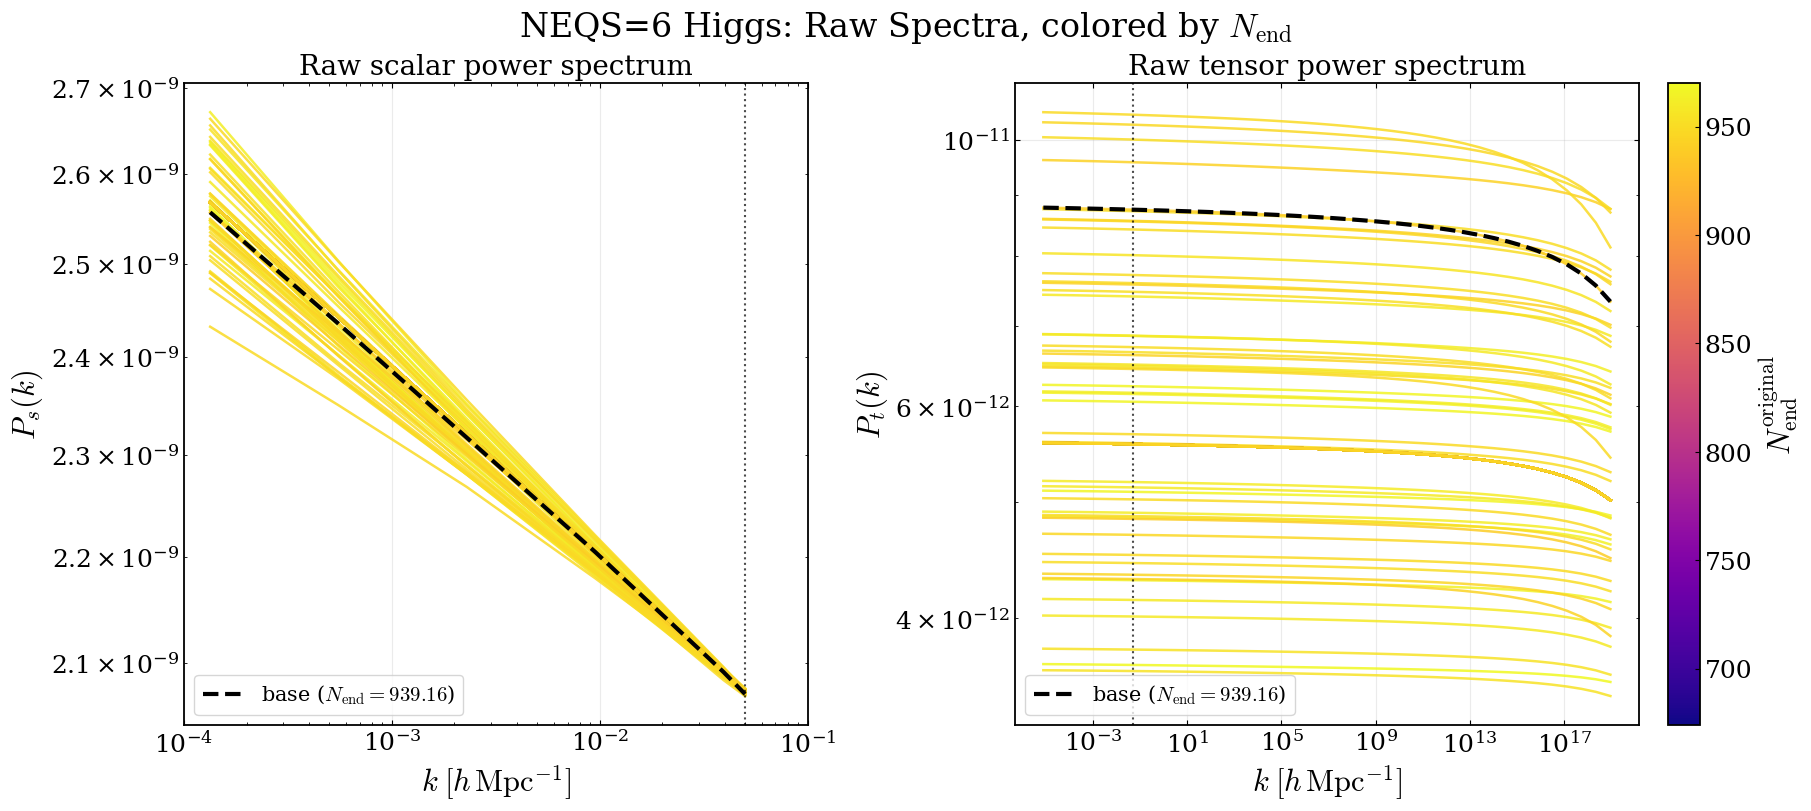

In [19]:
# ============================================================
# CELL 4 (revised): Plot raw, unshifted power spectra
#
# Same raw Ps(k)/Pt(k) curves as before, but now:
#   - uses the same "paper-ready" matplotlib style as
#     plot_filtered_spectra_by_ns_colored_by_Nend
#   - colors each curve by original_N_end (pulled from the
#     summary CSVs), not by lam5 -- since your batches vary
#     more than just lam5, N_end is the more meaningful axis
# ============================================================

# --- Paper-ready plot style ----------------------------------------
# NOTE: this affects every plot made for the rest of the kernel
# session, not just this cell. Consider moving this block to its
# own "set style" cell near the top of the notebook and running it
# once, instead of repeating it in every plotting function.
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 22,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

NEQS = 6
model_tag = "higgs"
scan_name, scan_symbol = SCAN_INFO[NEQS]
k_ref = 0.05  # your pivot scale, hMpc^-1

lam_values = sanitize_lam_values(param_values_by_model[model_tag][NEQS])
base_val = MODEL_CONFIG[model_tag]["lam_base"][NEQS][1]

# --- Pull N_end for each model from the summary CSVs -----------------
summary_all = load_batch_summaries(NEQS, base_path_root, model_tag=model_tag)


def get_Nend(value):
    """Look up original_N_end for one lam5 value from the summary table."""
    row_match = summary_all.loc[np.isclose(summary_all[scan_name], value)]
    if len(row_match) == 0:
        return None
    return float(row_match.iloc[0]["original_N_end"])


# Collect (lam_val, N_end, k_s, Ps, k_t, Pt) for every model we can load
loaded_models = []
for lam_val in lam_values:
    Nend = get_Nend(lam_val)
    if Nend is None:
        print(f"No summary row for {scan_name}={lam_val:.5e}, skipping")
        continue

    try:
        k_s, Ps, k_t, Pt = load_specs(
            NEQS,
            scan_name,
            lam_val,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )
    except FileNotFoundError as e:
        print(f"Skipping {scan_name}={lam_val:.5e}: {e}")
        continue

    loaded_models.append((lam_val, Nend, k_s, Ps, k_t, Pt))

Nends = np.array([m[1] for m in loaded_models])

# --- Color scale based on N_end, not lam5 -----------------------------
cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(vmin=np.nanmin(Nends), vmax=np.nanmax(Nends))

fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

for lam_val, Nend, k_s, Ps, k_t, Pt in loaded_models:
    color = cmap(norm(Nend))
#     ax_s.loglog(k_s, Ps, color=color, lw=1.8, alpha=0.85)
#     ax_t.loglog(k_t, Pt, color=color, lw=1.8, alpha=0.85)

    scalar_mask = (
        (k_s >= K_SCALAR_MIN)
        & (k_s <= K_SCALAR_MAX)
    )

    ax_s.loglog(
        k_s[scalar_mask],
        Ps[scalar_mask],
        color=color,
        lw=1.8,
        alpha=0.85,
    )

    ax_t.loglog(
        k_t,
        Pt,
        color=color,
        lw=1.8,
        alpha=0.85,
    )

# overplot the base model in black for reference
Nend_base = get_Nend(base_val)
k_s_base, Ps_base, k_t_base, Pt_base = load_specs(
    NEQS,
    scan_name,
    base_val,
    base_path_root=base_path_root,
    model_tag=model_tag,
)
base_label = (
    rf"base ($N_{{\rm end}}={Nend_base:.2f}$)"
    if Nend_base is not None
    else "base model"
)
# ax_s.loglog(k_s_base, Ps_base, color="black", lw=3, ls="--", label=base_label)

base_scalar_mask = (
    (k_s_base >= K_SCALAR_MIN)
    & (k_s_base <= K_SCALAR_MAX)
)

ax_s.loglog(
    k_s_base[base_scalar_mask],
    Ps_base[base_scalar_mask],
    color="black",
    lw=3,
    ls="--",
    label=base_label,
)
ax_t.loglog(k_t_base, Pt_base, color="black", lw=3, ls="--", label=base_label)

for ax, title, ylabel in [
    (ax_s, "Raw scalar power spectrum", r"$P_s(k)$"),
    (ax_t, "Raw tensor power spectrum", r"$P_t(k)$"),
]:
    ax.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()
    
    
ax_s.set_xlim(K_SCALAR_MIN, K_SCALAR_MAX)
ax_s.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax_t.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_s, ax_t], pad=0.02)
cbar.set_label(r"$N_{\rm end}^{\rm original}$")
cbar.ax.tick_params(direction="in")

fig.suptitle(f"NEQS={NEQS} {MODEL_CONFIG[model_tag]['label']}: Raw Spectra, colored by $N_{{\\rm end}}$")

fig.savefig(
    f"paper_{model_tag}_neqs{NEQS}_{scan_name}_raw_spectra_colored_by_Nend.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# CONFIRM CMB MODELS

Total accepted models loaded: 203
Models passing CMB cut: 203
Models FAILING CMB cut: 0
All accepted models pass the pivot-scale cut. YOU GO GIRL

r_flow vs r_spec cross-check (nearest-k, no interpolation):
  mean |delta_r| = 9.227e-05
  max  |delta_r| = 1.716e-04


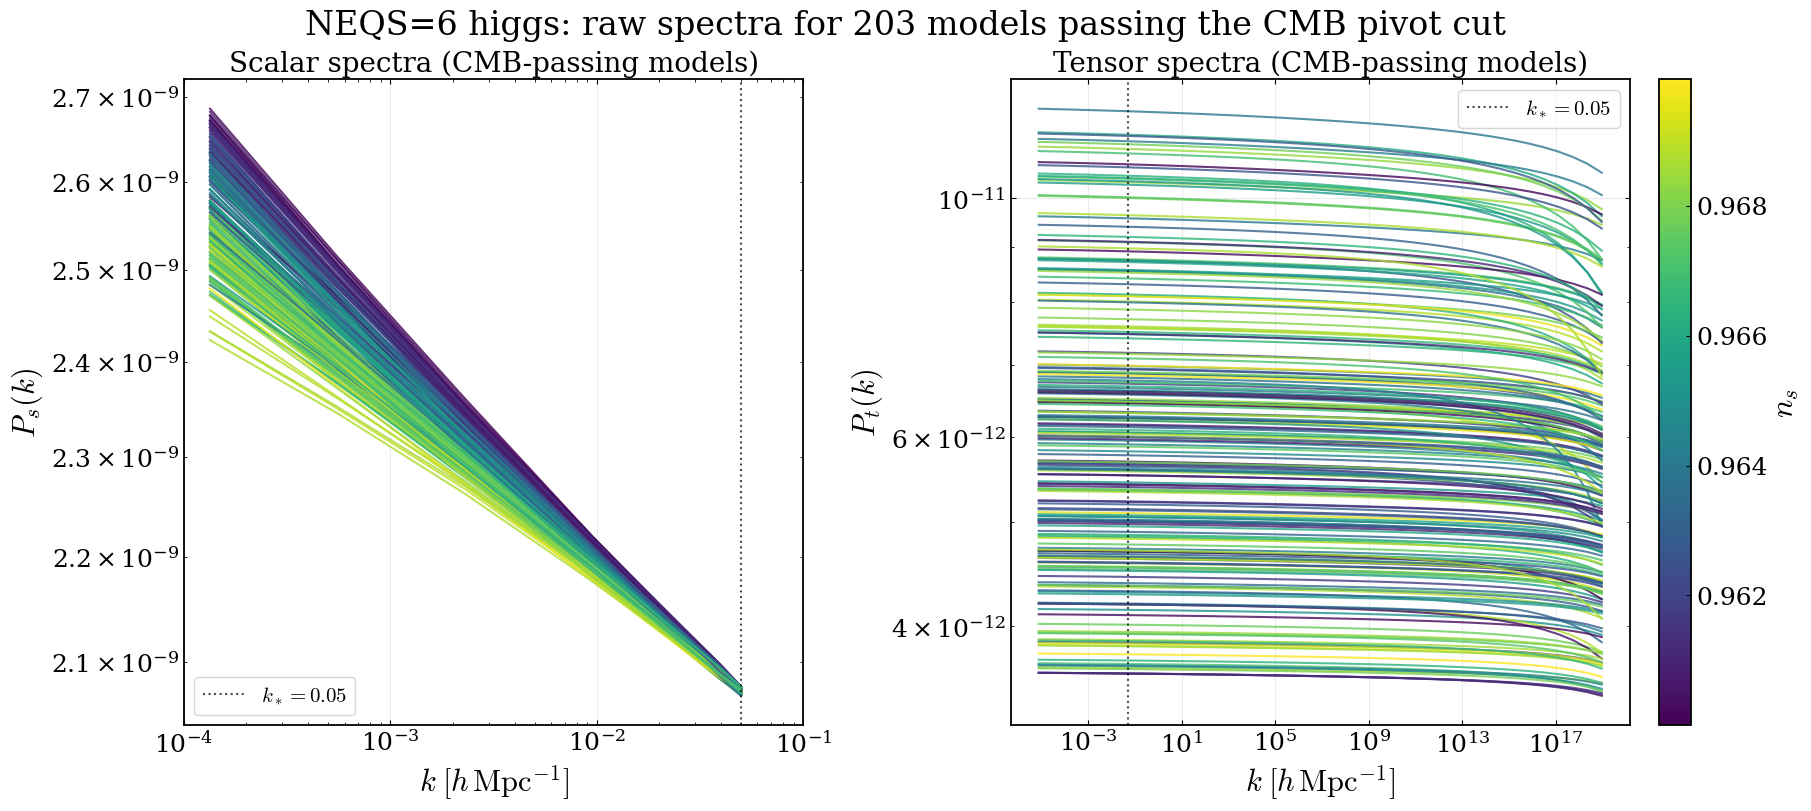

In [20]:
# ============================================================
# CELL 5: Confirm r (and the CMB cut) at the pivot scale
#
# NOTE: looking at the driver script, `r`, `n_s`, `alpha_s` saved
# in the summary CSV are evaluated at N_CMB = 55, not N = 60
# (the driver evolves the state from N=60 down to N=55 with
# get_state_at_N before computing tsratio/specindex/dspecindex).
# So r_flow already corresponds to ~ the same place as k_pivot=0.05.
# The small delta_r you saw earlier is spectrum discretization
# (only 41 saved k-points, nearest-neighbor lookup), not an
# N=60-vs-N=55 mismatch.
# ============================================================

NEQS = 6
model_tag = "higgs"
k_pivot = 0.05

# --- Reproduce the driver's CMB acceptance window -------------------
PIVOT_NMIN, PIVOT_NMAX = 0.96, 0.97

R_TARGET = 0.003664125
R_DELTA = 0.002
PIVOT_RMIN = R_TARGET - R_DELTA
PIVOT_RMAX = R_TARGET + R_DELTA


ALPHA_TARGET = -0.000630587
ALPHA_DELTA = 0.002


PIVOT_ALPHA_MIN = ALPHA_TARGET - ALPHA_DELTA
PIVOT_ALPHA_MAX = ALPHA_TARGET + ALPHA_DELTA

# --- Load every accepted model across all batches --------------------
summary_all = load_batch_summaries(NEQS, base_path_root, model_tag=model_tag)
print(f"Total accepted models loaded: {len(summary_all)}")

# --- Re-apply the same cut the driver already enforced -----------------
# This is the "super duper check" -- everything SHOULD pass, since the
# accept/reject decision already happened at generation time.
pass_ns = (PIVOT_NMIN < summary_all["n_s"]) & (summary_all["n_s"] < PIVOT_NMAX)
pass_r = (PIVOT_RMIN < summary_all["r"]) & (summary_all["r"] < PIVOT_RMAX)
pass_alpha = (
    (PIVOT_ALPHA_MIN < summary_all["alpha_s"])
    & (summary_all["alpha_s"] < PIVOT_ALPHA_MAX)
)

summary_all["passes_cmb_cut"] = pass_ns & pass_r & pass_alpha

n_pass = int(summary_all["passes_cmb_cut"].sum())
n_fail = int((~summary_all["passes_cmb_cut"]).sum())

print(f"Models passing CMB cut: {n_pass}")
print(f"Models FAILING CMB cut: {n_fail}")

if n_fail > 0:
    print("\nModels that failed the check (should be empty!):")
    fail_cols = ["outdir", "n_s", "r", "alpha_s"]
    print(
        summary_all.loc[~summary_all["passes_cmb_cut"], fail_cols]
        .to_string(index=False)
    )
else:
    print("All accepted models pass the pivot-scale cut. YOU GO GIRL")


# --- Cross-check r_flow against r computed directly from the spectra ---
def r_spec_at_pivot(outdir, k_pivot=k_pivot):
    """Nearest-k lookup of Pt/Ps at k_pivot, straight from the saved spectra."""
    s = np.loadtxt(os.path.join(outdir, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(outdir, f"spec_t_neqs{NEQS}.dat"))
    k_s, Ps = s[:, 0], s[:, 1]
    k_t, Pt = t[:, 0], t[:, 1]
    i_s = np.argmin(np.abs(k_s - k_pivot))
    i_t = np.argmin(np.abs(k_t - k_pivot))
    return Pt[i_t] / Ps[i_s]


r_spec_vals = []
for _, row in summary_all.iterrows():
    try:
        r_spec_vals.append(r_spec_at_pivot(row["outdir"]))
    except (OSError, FileNotFoundError) as e:
        print(f"Could not load spectra for {row['outdir']}: {e}")
        r_spec_vals.append(np.nan)

summary_all["r_spec"] = r_spec_vals
summary_all["delta_r"] = summary_all["r_spec"] - summary_all["r"]

print("\nr_flow vs r_spec cross-check (nearest-k, no interpolation):")
print(f"  mean |delta_r| = {summary_all['delta_r'].abs().mean():.3e}")
print(f"  max  |delta_r| = {summary_all['delta_r'].abs().max():.3e}")


# --- Plot raw spectra for all CMB-passing models, colored by n_s --------
# (Run the paper-style rcParams block from Cell 4 first if you haven't
# already this session -- it persists for the rest of the kernel.)
passing = summary_all[summary_all["passes_cmb_cut"]].copy()

cmap = plt.get_cmap("viridis")
norm = mcolors.Normalize(vmin=passing["n_s"].min(), vmax=passing["n_s"].max())

# K_SCALAR_MIN = 1e-4
# K_SCALAR_MAX = 1e-1


fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

for _, row in passing.iterrows():
    try:
        s = np.loadtxt(os.path.join(row["outdir"], f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(row["outdir"], f"spec_t_neqs{NEQS}.dat"))
    except (OSError, FileNotFoundError):
        continue

    color = cmap(norm(row["n_s"]))
#     ax_s.loglog(s[:, 0], s[:, 1], color=color, lw=1.5, alpha=0.8)
#     ax_t.loglog(t[:, 0], t[:, 1], color=color, lw=1.5, alpha=0.8)


    scalar_mask = (
        (s[:, 0] >= K_SCALAR_MIN)
        & (s[:, 0] <= K_SCALAR_MAX)
    )

    ax_s.loglog(
        s[scalar_mask, 0],
        s[scalar_mask, 1],
        color=color,
        lw=1.5,
        alpha=0.8,
    )

    ax_t.loglog(
        t[:, 0],
        t[:, 1],
        color=color,
        lw=1.5,
        alpha=0.8,
    )

for ax, title, ylabel in [
    (ax_s, "Scalar spectra (CMB-passing models)", r"$P_s(k)$"),
    (ax_t, "Tensor spectra (CMB-passing models)", r"$P_t(k)$"),
]:
    ax.axvline(k_pivot, color="black", ls=":", alpha=0.7, label=rf"$k_*={k_pivot}$")
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()
    
ax_s.set_xlim(K_SCALAR_MIN, K_SCALAR_MAX)
ax_s.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax_t.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_s, ax_t], pad=0.02)
cbar.set_label(r"$n_s$")

fig.suptitle(
    f"NEQS={NEQS} {model_tag}: raw spectra for "
    f"{len(passing)} models passing the CMB pivot cut"
)
plt.show()

# BACKGROUND DYNAMICS OF CMB PASSING MODELS

Processed 203 / 203 CMB-passing models


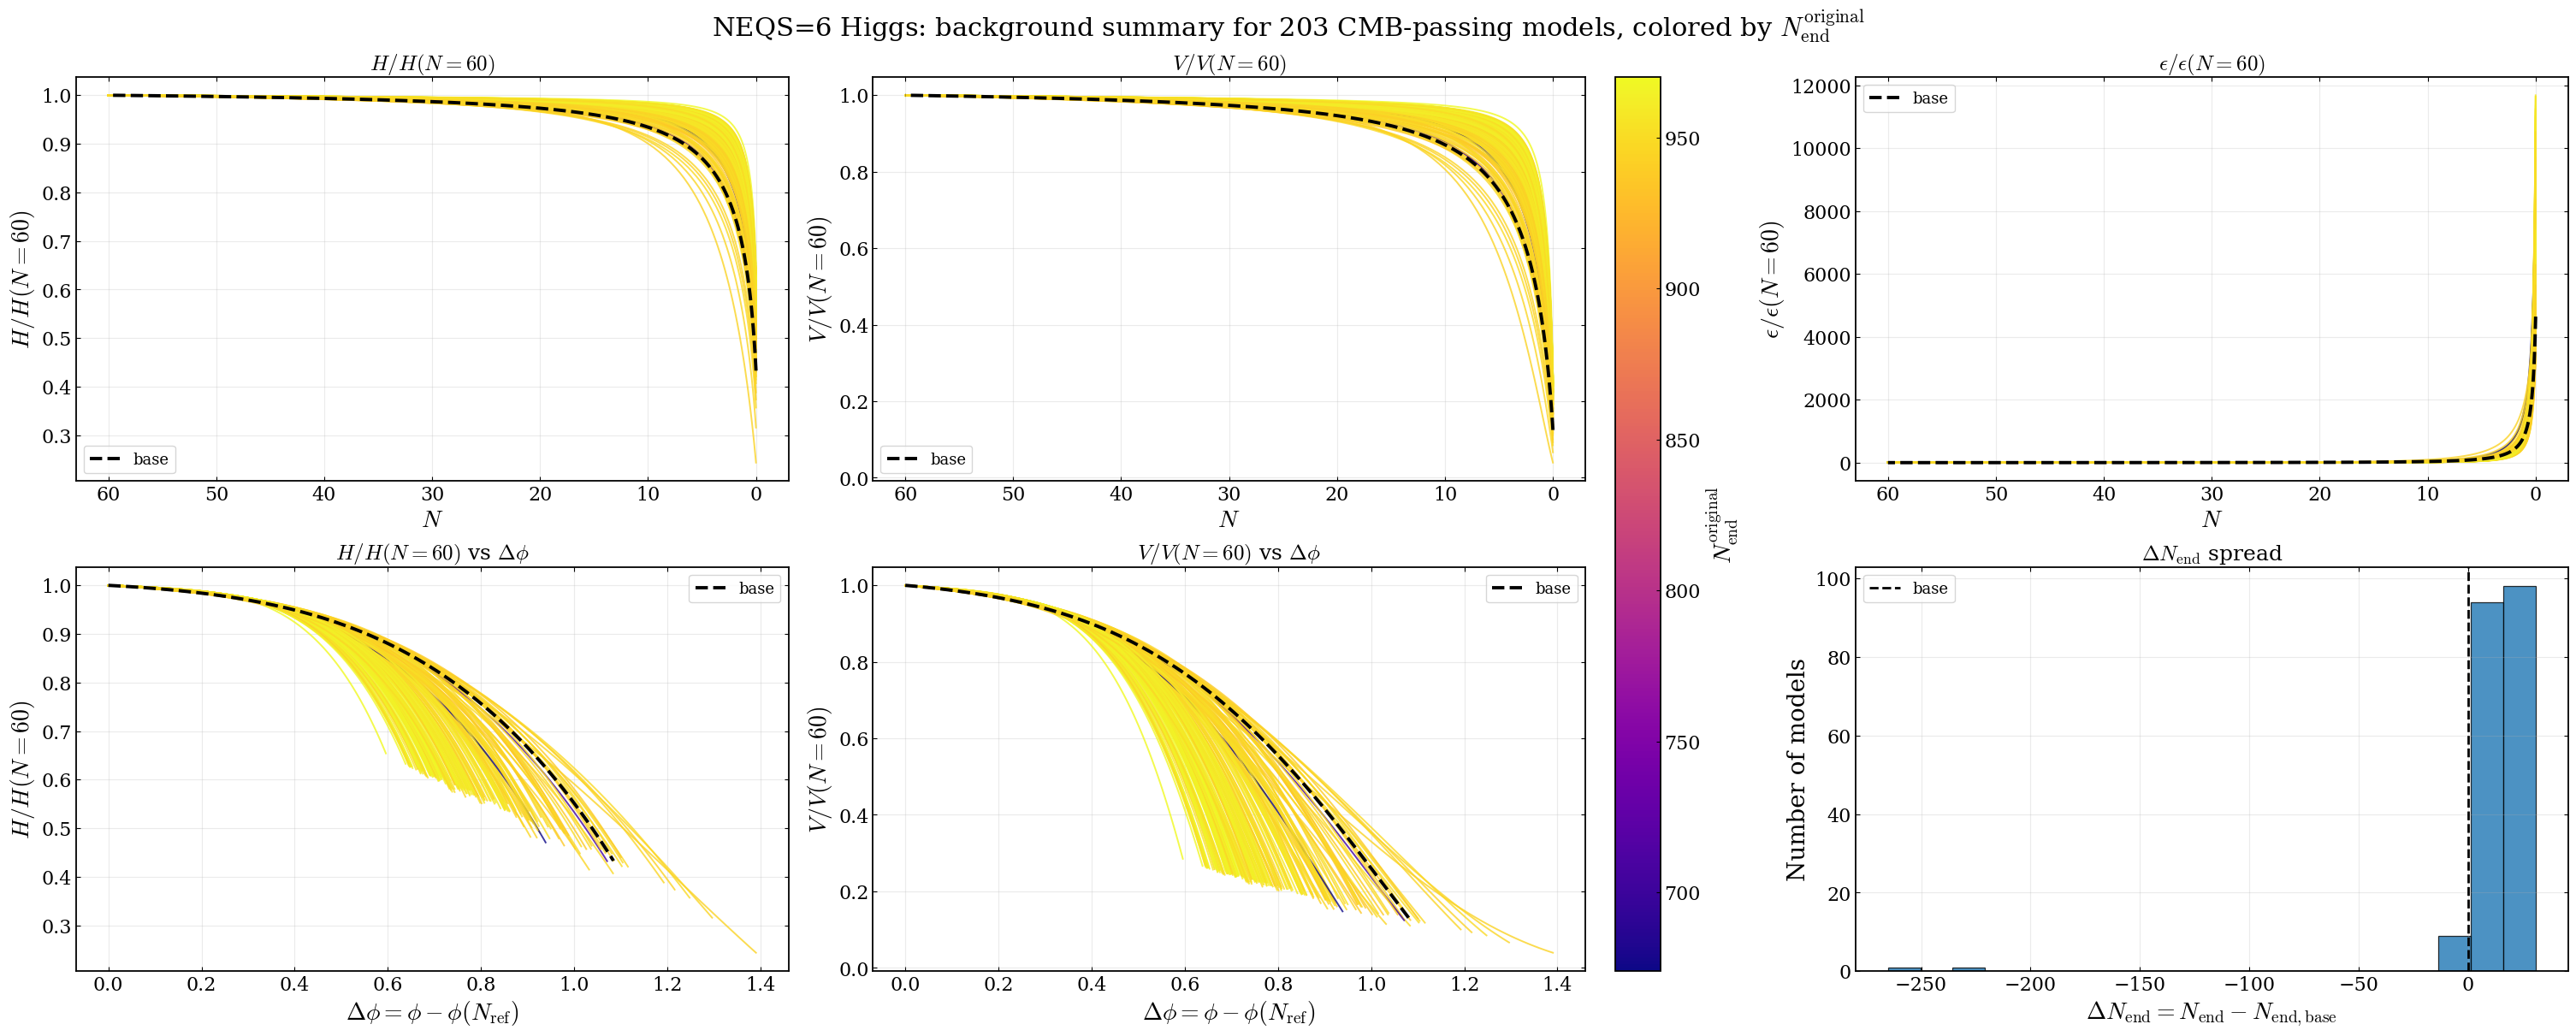


Higgs (NEQS=6)
Models plotted   : 203
Base N_end       : 939.163572
Median |deltaN|  : 15.559
Mean |deltaN|    : 17.569
Max |deltaN|     : 265.178


In [21]:
# ============================================================
# CELL 6: Combined background summary plot for CMB-passing models
#
# Panels: H(N), V(N), eps(N)  [normalized at N_ref]
#         H(phi), V(phi)      [normalized at N_ref, vs delta_phi]
#         deltaN spread histogram (N_end - N_end_base)
#
# Uses the `passing` DataFrame built in Cell 5 (CMB-cut models,
# with an `outdir` column pointing straight at each model's folder).
# ============================================================

plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 13,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

NEQS = 6
model_tag = "higgs"
N_ref = 60.0


# --- Load one model's raw path file directly from its outdir -----------
def load_path_from_outdir(outdir, NEQS=NEQS):
    folder = Path(outdir)
    matches = list(
        folder.glob(f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat")
    )
    if not matches:
        raise FileNotFoundError(f"No path file found in: {outdir}")
    return pd.read_csv(matches[0], sep=r"\s+", header=None).values


# --- Process one model's trajectory into everything the plot needs -----
def process_trajectory(data, N_ref=N_ref, NEQS=NEQS):
    """
    From raw path data, return N-aligned and phi-aligned normalized
    curves for H, V, and eps, all anchored at N_ref.
    """
    phi_raw = np.asarray(data[:, 0], dtype=float)
    H_raw = np.asarray(data[:, 1], dtype=float)
    eps_raw = np.asarray(data[:, 2], dtype=float)
    N_raw = np.asarray(data[:, NEQS], dtype=float)
    V_raw = np.asarray(data[:, NEQS + 1], dtype=float)

    finite = (
        np.isfinite(phi_raw)
        & np.isfinite(H_raw)
        & np.isfinite(eps_raw)
        & np.isfinite(N_raw)
        & np.isfinite(V_raw)
    )
    phi_raw, H_raw, eps_raw, N_raw, V_raw = (
        phi_raw[finite], H_raw[finite], eps_raw[finite], N_raw[finite], V_raw[finite]
    )

    if len(N_raw) < 2:
        raise ValueError("Not enough finite path points.")

    # Order everything consistently by N
    dN = np.diff(N_raw)
    if np.all(dN >= 0):
        N_use, phi_use, H_use, eps_use, V_use = N_raw, phi_raw, H_raw, eps_raw, V_raw
    elif np.all(dN <= 0):
        N_use = N_raw[::-1]
        phi_use = phi_raw[::-1]
        H_use = H_raw[::-1]
        eps_use = eps_raw[::-1]
        V_use = V_raw[::-1]
    else:
        raise ValueError("N is non-monotonic; refusing to reorder trajectory.")

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min():.4f}, {N_use.max():.4f}]"
        )

    # Reference values at N_ref
    phi_ref = np.interp(N_ref, N_use, phi_use)
    H_ref = np.interp(N_ref, N_use, H_use)
    eps_ref = np.interp(N_ref, N_use, eps_use)
    V_ref = np.interp(N_ref, N_use, V_use)

    if not (np.isfinite(H_ref) and abs(H_ref) > 1e-30):
        raise ValueError(f"Invalid H_ref at N_ref={N_ref}: {H_ref}")
    if not (np.isfinite(V_ref) and abs(V_ref) > 1e-30):
        raise ValueError(f"Invalid V_ref at N_ref={N_ref}: {V_ref}")
    if not (np.isfinite(eps_ref) and abs(eps_ref) > 1e-30):
        raise ValueError(f"Invalid eps_ref at N_ref={N_ref}: {eps_ref}")

    # N-aligned normalized curves
    H_norm_N = H_use / H_ref
    V_norm_N = V_use / V_ref
    eps_norm_N = eps_use / eps_ref

    # phi-aligned normalized curves
    delta_phi = phi_use - phi_ref
    H_norm_phi = H_use / H_ref
    V_norm_phi = V_use / V_ref

    dphi = np.diff(delta_phi)
    if np.all(dphi >= 0):
        pass
    elif np.all(dphi <= 0):
        delta_phi = delta_phi[::-1]
        H_norm_phi = H_norm_phi[::-1]
        V_norm_phi = V_norm_phi[::-1]
    else:
        raise ValueError("phi is non-monotonic; V(phi)/H(phi) would be multivalued.")

    return {
        "N": N_use,
        "H_norm_N": H_norm_N,
        "V_norm_N": V_norm_N,
        "eps_norm_N": eps_norm_N,
        "delta_phi": delta_phi,
        "H_norm_phi": H_norm_phi,
        "V_norm_phi": V_norm_phi,
    }


# --- Find the base model's row (for the black dashed overlay) -----------
base_val = MODEL_CONFIG[model_tag]["lam_base"][NEQS][1]
base_mask = np.isclose(
    summary_all["lam3"].to_numpy(dtype=float),
    base_val,
    rtol=1e-8,
    atol=max(1e-15, abs(base_val) * 1e-8),
)
base_row = summary_all.loc[base_mask].iloc[0]
base_N_end = float(base_row["original_N_end"])
base_curves = process_trajectory(load_path_from_outdir(base_row["outdir"]))

# --- Process every CMB-passing model ------------------------------------
processed = []
for _, row in passing.iterrows():
    try:
        data = load_path_from_outdir(row["outdir"])
        curves = process_trajectory(data)
        processed.append({
            **curves,
            "original_N_end": float(row["original_N_end"]),
            "deltaN_from_base": float(row["original_N_end"]) - base_N_end,
        })
    except (FileNotFoundError, ValueError) as e:
        print(f"Skipping {row['outdir']}: {e}")

print(f"Processed {len(processed)} / {len(passing)} CMB-passing models")

Nend_vals = np.array([m["original_N_end"] for m in processed])
cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(vmin=np.nanmin(Nend_vals), vmax=np.nanmax(Nend_vals))

# --- Build the 2x3 summary figure ----------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(30, 12), constrained_layout=True)
ax_HN, ax_VN, ax_epsN = axes[0]
ax_Hphi, ax_Vphi, ax_hist = axes[1]

for m in processed:
    color = cmap(norm(m["original_N_end"]))
    ax_HN.plot(m["N"], m["H_norm_N"], color=color, lw=1.4, alpha=0.8)
    ax_VN.plot(m["N"], m["V_norm_N"], color=color, lw=1.4, alpha=0.8)
    ax_epsN.plot(m["N"], m["eps_norm_N"], color=color, lw=1.4, alpha=0.8)
    ax_Hphi.plot(m["delta_phi"], m["H_norm_phi"], color=color, lw=1.4, alpha=0.8)
    ax_Vphi.plot(m["delta_phi"], m["V_norm_phi"], color=color, lw=1.4, alpha=0.8)

# base model overlay (black dashed) on all N/phi panels
ax_HN.plot(base_curves["N"], base_curves["H_norm_N"], color="black", lw=2.8, ls="--", label="base")
ax_VN.plot(base_curves["N"], base_curves["V_norm_N"], color="black", lw=2.8, ls="--", label="base")
ax_epsN.plot(base_curves["N"], base_curves["eps_norm_N"], color="black", lw=2.8, ls="--", label="base")
ax_Hphi.plot(base_curves["delta_phi"], base_curves["H_norm_phi"], color="black", lw=2.8, ls="--", label="base")
ax_Vphi.plot(base_curves["delta_phi"], base_curves["V_norm_phi"], color="black", lw=2.8, ls="--", label="base")

# deltaN histogram (no per-model color; it's an aggregate count, not a line)
deltaN_vals = np.array([m["deltaN_from_base"] for m in processed])
ax_hist.hist(deltaN_vals, bins=20, alpha=0.8, edgecolor="black", linewidth=0.9)
ax_hist.axvline(0.0, color="black", ls="--", lw=2.0, label="base")

# --- Titles / labels -----------------------------------------------------
ax_HN.set_title(rf"$H/H(N={N_ref:g})$")
ax_VN.set_title(rf"$V/V(N={N_ref:g})$")
ax_epsN.set_title(rf"$\epsilon/\epsilon(N={N_ref:g})$")
ax_Hphi.set_title(rf"$H/H(N={N_ref:g})$ vs $\Delta\phi$")
ax_Vphi.set_title(rf"$V/V(N={N_ref:g})$ vs $\Delta\phi$")
ax_hist.set_title(r"$\Delta N_{\rm end}$ spread")

for ax in [ax_HN, ax_VN, ax_epsN]:
    ax.set_xlabel(r"$N$")
    ax.invert_xaxis()

ax_HN.set_ylabel(rf"$H/H(N={N_ref:g})$")
ax_VN.set_ylabel(rf"$V/V(N={N_ref:g})$")
ax_epsN.set_ylabel(rf"$\epsilon/\epsilon(N={N_ref:g})$")

ax_Hphi.set_xlabel(r"$\Delta\phi=\phi-\phi(N_{\rm ref})$")
ax_Vphi.set_xlabel(r"$\Delta\phi=\phi-\phi(N_{\rm ref})$")
ax_Hphi.set_ylabel(rf"$H/H(N={N_ref:g})$")
ax_Vphi.set_ylabel(rf"$V/V(N={N_ref:g})$")

ax_hist.set_xlabel(r"$\Delta N_{\rm end}=N_{\rm end}-N_{\rm end,base}$")
ax_hist.set_ylabel("Number of models")

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend()

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, :2].ravel().tolist(), pad=0.02)
cbar.set_label(r"$N_{\rm end}^{\rm original}$")
cbar.ax.tick_params(direction="in")

# Force plain numbers (e.g. "946") instead of an offset/scientific notation
# (e.g. "+9.463e2") on the colorbar ticks.
cbar_formatter = ScalarFormatter(useOffset=False)
cbar_formatter.set_scientific(False)
cbar.formatter = cbar_formatter
cbar.update_ticks()

fig.suptitle(
    rf"NEQS={NEQS} {MODEL_CONFIG[model_tag]['label']}: "
    rf"background summary for {len(processed)} CMB-passing models, "
    r"colored by $N_{\rm end}^{\rm original}$"
)

fig.savefig(
    f"paper_{model_tag}_neqs{NEQS}_background_summary_colored_by_Nend.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# --- Console summary -------------------------------------------------------
print("\n" + "=" * 60)
print(f"{MODEL_CONFIG[model_tag]['label']} (NEQS={NEQS})")
print("=" * 60)
print(f"Models plotted   : {len(processed)}")
print(f"Base N_end       : {base_N_end:.6f}")
print(f"Median |deltaN|  : {np.median(np.abs(deltaN_vals)):.3f}")
print(f"Mean |deltaN|    : {np.mean(np.abs(deltaN_vals)):.3f}")
print(f"Max |deltaN|     : {np.max(np.abs(deltaN_vals)):.3f}")

# CORNER PLOTS

Models in mixed grid: 203


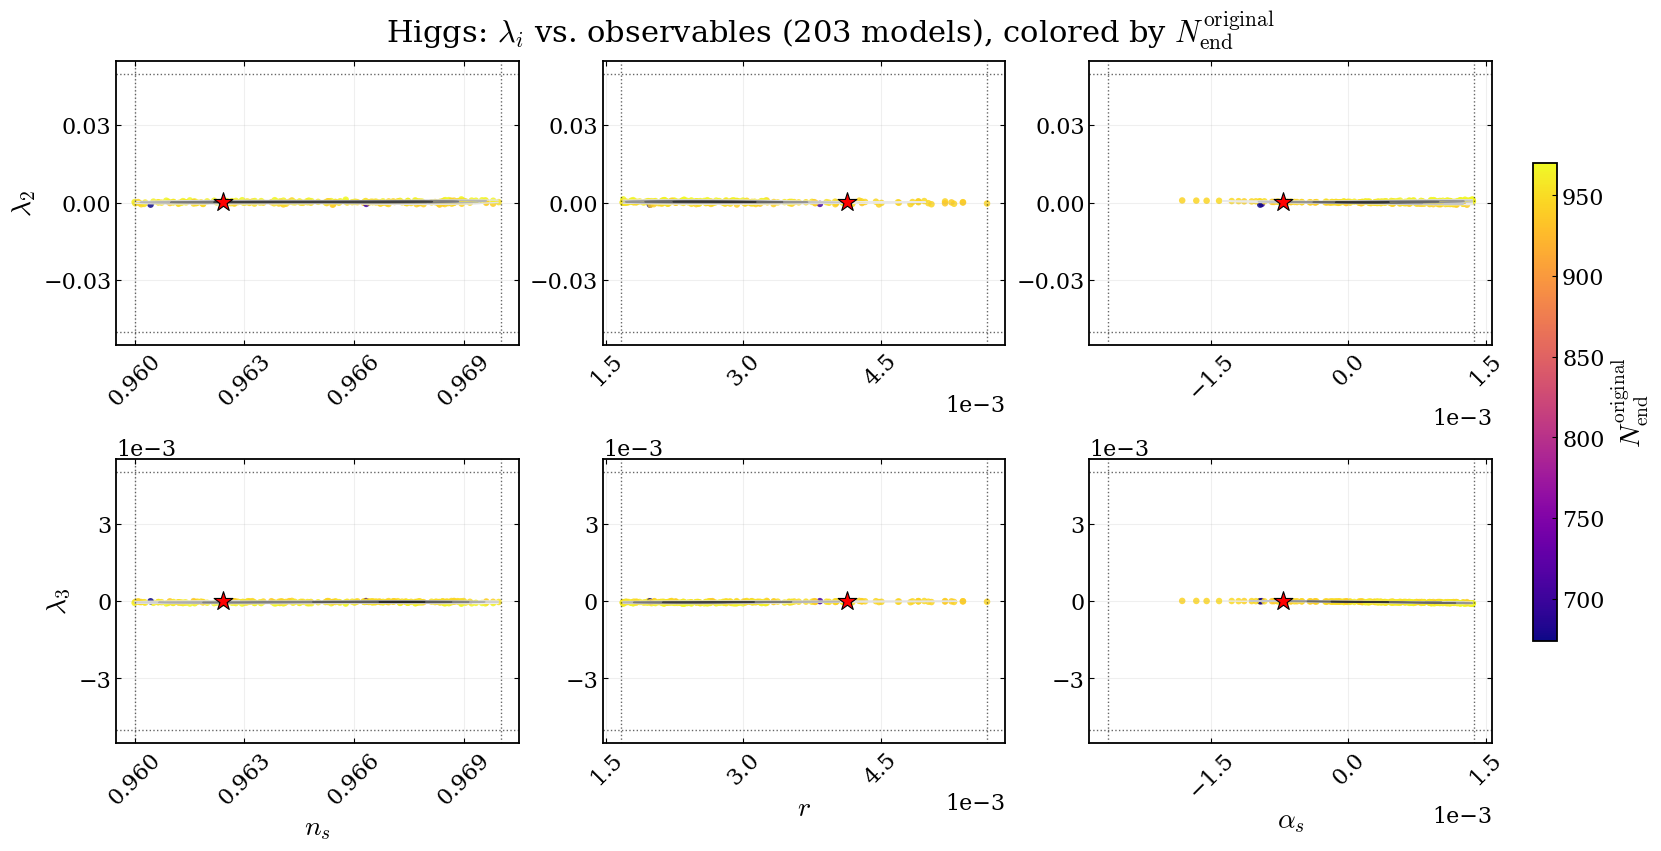

In [22]:
# ============================================================
# CELL 9: Mixed grid -- lam2, lam3, lam4, lam5 (rows) vs.
#          n_s, r, alpha_s (columns)
#
# Not a triangle -- every panel is filled, since rows and columns
# are different quantities. Useful for spotting which lambda
# mainly drives which observable (a degeneracy-breaking view),
# rather than the pairwise structure within one variable group.
#
# Vertical dashed lines: your observable acceptance window.
# Horizontal dashed lines: the driver's sampling prior for that lambda.
# ============================================================

from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter, MaxNLocator


# --- Self-contained copies of the Cell 7b helpers --------------------------
# (duplicated here so this cell works even if Cell 7b hasn't run yet
# this session)
def add_kde_contour(ax, x, y, levels=5, min_points=10, cmap="Greys"):
    if len(x) < min_points:
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
        xg = np.linspace(x.min(), x.max(), 100)
        yg = np.linspace(y.min(), y.max(), 100)
        XG, YG = np.meshgrid(xg, yg)
        ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
        ax.contour(XG, YG, ZG, levels=levels, cmap=cmap, linewidths=1.0)
    except np.linalg.LinAlgError:
        pass


def format_no_offset(ax, max_ticks=4):
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_ticks, prune="both"))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=max_ticks, prune="both"))
    x_fmt = ScalarFormatter(useOffset=False)
    x_fmt.set_powerlimits((-3, 3))
    ax.xaxis.set_major_formatter(x_fmt)
    y_fmt = ScalarFormatter(useOffset=False)
    y_fmt.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(y_fmt)
    ax.tick_params(axis="x", labelrotation=45)


NEQS = 6
model_tag = "higgs"

# --- Rows: theory parameters, with their sampling prior + base value ------
# row_columns = ["lam2", "lam3", "lam4", "lam5"]
row_columns = ["lam2", "lam3"]

row_labels = {
    "lam2": r"$\lambda_2$",
    "lam3": r"$\lambda_3$"
#     "lam4": r"$\lambda_4$",
#     "lam5": r"$\lambda_5$",
}
param_bounds = {
    "lam2": (-5e-2, 5e-2),
    "lam3": (-5e-3, 5e-3)
#     "lam4": (-5e-4, 5e-4),
#     "lam5": (-5e-5, 5e-5),
}
param_base = {
    "lam2": 0.000278972,
    "lam3": -4.60971e-6
#     "lam4": 6.87065e-08,
#     "lam5": -8.92461e-9,
}

# --- Columns: CMB observables, with their acceptance window + base value --
col_columns = ["n_s", "r", "alpha_s"]
col_labels = {
    "n_s": r"$n_s$",
    "r": r"$r$",
    "alpha_s": r"$\alpha_s$",
}

PIVOT_NMIN, PIVOT_NMAX = 0.96, 0.97
R_TARGET, R_DELTA = 0.003664125, 0.002
PIVOT_RMIN, PIVOT_RMAX = R_TARGET - R_DELTA, R_TARGET + R_DELTA
ALPHA_TARGET = -0.000630587
ALPHA_DELTA = 0.002

PIVOT_ALPHA_MIN = ALPHA_TARGET - ALPHA_DELTA
PIVOT_ALPHA_MAX = ALPHA_TARGET + ALPHA_DELTA

# PIVOT_ALPHA_MIN, PIVOT_ALPHA_MAX = -0.000630587, 0.000630587

cut_bounds = {
    "n_s": (PIVOT_NMIN, PIVOT_NMAX),
    "r": (PIVOT_RMIN, PIVOT_RMAX),
    "alpha_s": (PIVOT_ALPHA_MIN, PIVOT_ALPHA_MAX),
}

# --- Base model row (for observable base values, e.g. n_s_base) -----------
summary_all = load_batch_summaries(NEQS, base_path_root, model_tag=model_tag)
base_mask = np.isclose(
    summary_all["lam3"].to_numpy(dtype=float),
    param_base["lam3"],
    rtol=1e-10,
    atol=max(1e-15, abs(param_base["lam3"]) * 1e-10),
)
base_row = summary_all.loc[base_mask].iloc[0]

# --- Data -------------------------------------------------------------------
needed_cols = row_columns + col_columns + ["original_N_end"]
df_grid = summary_all[needed_cols].dropna().copy()
n_models = len(df_grid)
print(f"Models in mixed grid: {n_models}")

cmap = plt.get_cmap("plasma")
color_norm = mcolors.Normalize(
    vmin=df_grid["original_N_end"].min(),
    vmax=df_grid["original_N_end"].max(),
)
point_colors = cmap(color_norm(df_grid["original_N_end"]))

# --- Build the grid -----------------------------------------------------------
n_rows = len(row_columns)
n_cols = len(col_columns)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5.5 * n_cols, 4.2 * n_rows),
    constrained_layout=True,
)

for i, row_name in enumerate(row_columns):
    for j, col_name in enumerate(col_columns):
        ax = axes[i, j]

        x = df_grid[col_name].to_numpy()
        y = df_grid[row_name].to_numpy()

        add_kde_contour(ax, x, y)

        ax.scatter(x, y, c=point_colors, s=22, edgecolor="none", alpha=0.85)
        ax.scatter(
            float(base_row[col_name]), param_base[row_name],
            marker="*", s=200, color="red",
            edgecolor="black", linewidth=0.8, zorder=10,
        )

        x_lo, x_hi = cut_bounds[col_name]
        ax.axvline(x_lo, color="black", ls=":", lw=1.0, alpha=0.6)
        ax.axvline(x_hi, color="black", ls=":", lw=1.0, alpha=0.6)

        y_lo, y_hi = param_bounds[row_name]
        ax.axhline(y_lo, color="black", ls=":", lw=1.0, alpha=0.6)
        ax.axhline(y_hi, color="black", ls=":", lw=1.0, alpha=0.6)

        if i == n_rows - 1:
            ax.set_xlabel(col_labels[col_name])
        if j == 0:
            ax.set_ylabel(row_labels[row_name])

        format_no_offset(ax)
        ax.grid(True, alpha=0.2)

sm = cm.ScalarMappable(cmap=cmap, norm=color_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02)
cbar.set_label(r"$N_{\rm end}^{\rm original}$")
cbar_fmt = ScalarFormatter(useOffset=False)
cbar_fmt.set_scientific(False)
cbar.formatter = cbar_fmt
cbar.update_ticks()

fig.suptitle(
    rf"{MODEL_CONFIG[model_tag]['label']}: $\lambda_i$ vs. observables "
    rf"({n_models} models), colored by $N_{{\rm end}}^{{\rm original}}$"
)

fig.savefig(
    f"paper_{model_tag}_neqs{NEQS}_lambda_vs_observable_grid.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Models in mixed grid: 203


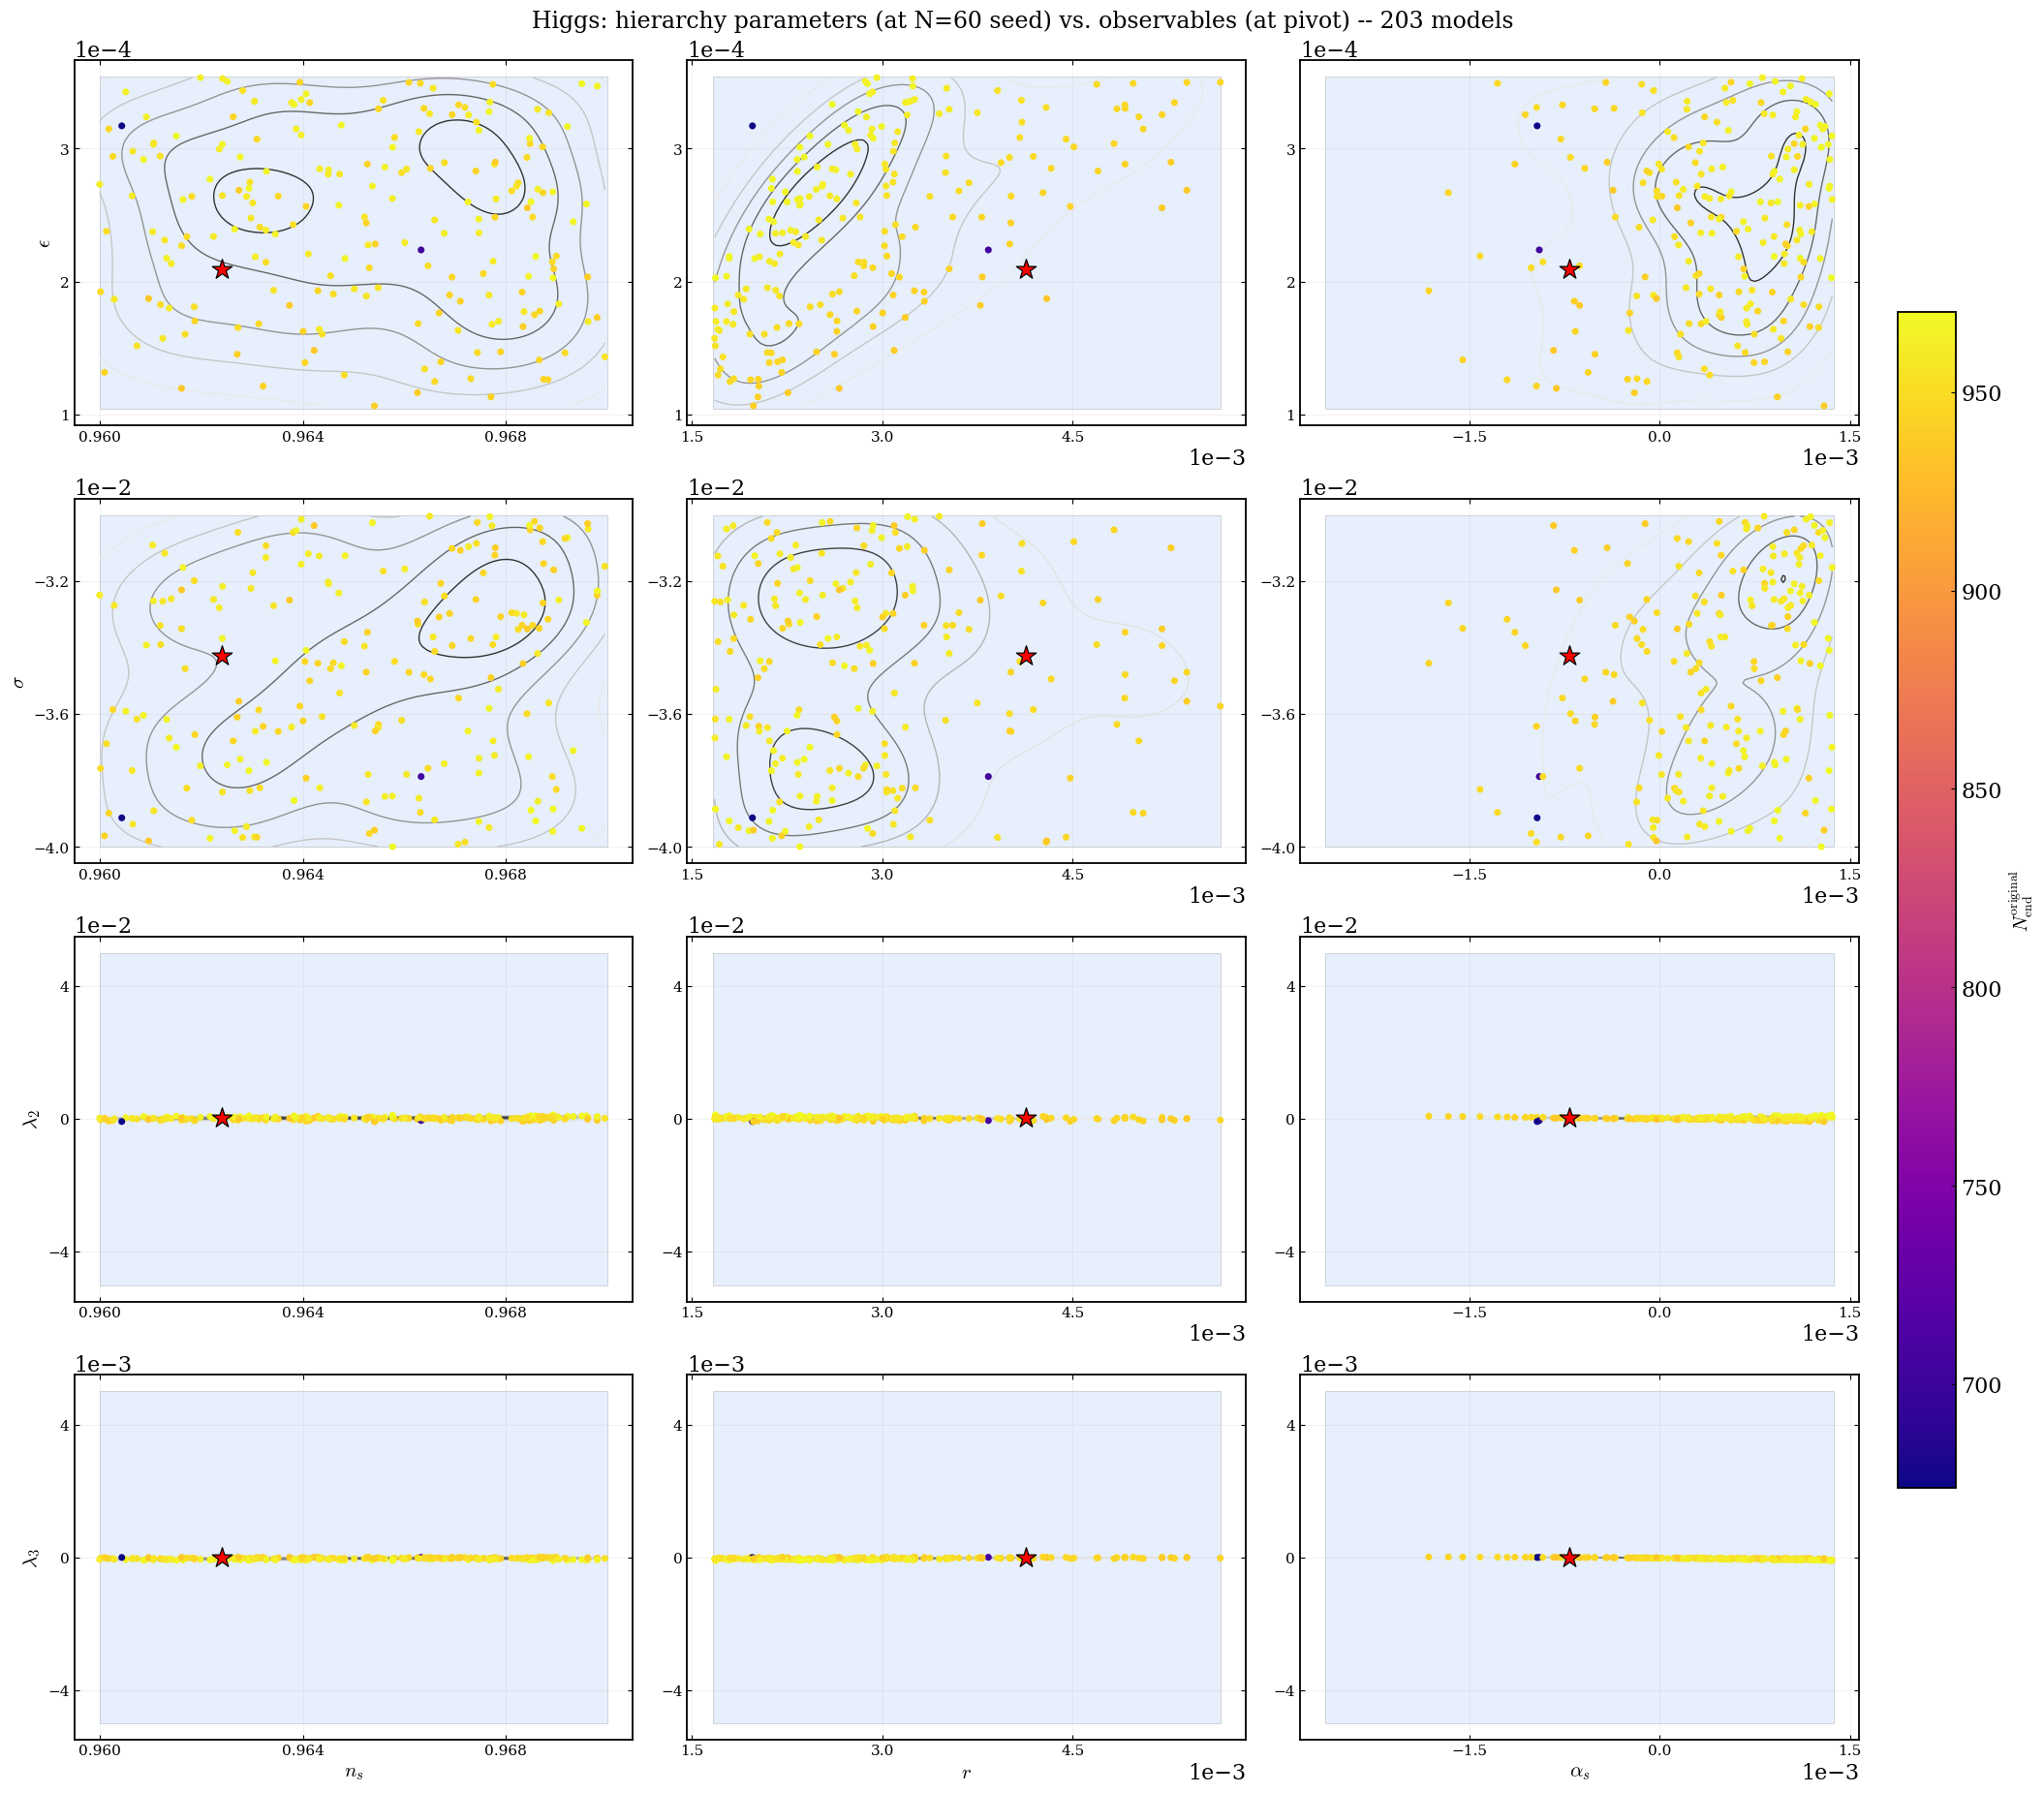

In [23]:
# ============================================================
# CELL 9: Mixed grid -- eps, sig, lam2, lam3, lam4, lam5 (rows) vs.
#          n_s, r, alpha_s (columns)
#
# Not a triangle -- every panel is filled, since rows and columns
# are different quantities. Useful for spotting which parameter
# mainly drives which observable (a degeneracy-breaking view).
#
# Shaded box per panel: x-range = your observable acceptance window,
# y-range = the driver's sampling prior for that row parameter.
#
# CAVEAT: all six row parameters (eps, sig, lam2-5) are the RAW
# SAMPLED VALUES that seeded each trajectory at N=60 -- NOT
# evaluated at your pivot N=55. n_s/r/alpha_s (columns) ARE
# pivot-scale (established back in Cell 5).
# ============================================================

from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from matplotlib.patches import Rectangle


def add_kde_contour(ax, x, y, levels=5, min_points=10, cmap="Greys"):
    if len(x) < min_points:
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
        xg = np.linspace(x.min(), x.max(), 100)
        yg = np.linspace(y.min(), y.max(), 100)
        XG, YG = np.meshgrid(xg, yg)
        ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
        ax.contour(XG, YG, ZG, levels=levels, cmap=cmap, linewidths=1.0)
    except np.linalg.LinAlgError:
        pass


def format_no_offset(ax, max_ticks=3):
    """Few, short tick labels: compact scientific notation, no offset."""
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_ticks, prune="both"))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=max_ticks, prune="both"))
    x_fmt = ScalarFormatter(useOffset=False)
    x_fmt.set_powerlimits((-2, 2))
    ax.xaxis.set_major_formatter(x_fmt)
    y_fmt = ScalarFormatter(useOffset=False)
    y_fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(y_fmt)


def add_reference_box(ax, x_bounds, y_bounds, color="cornflowerblue", alpha=0.15):
    """One soft shaded rectangle, instead of dashed lines crossing the panel."""
    x_lo, x_hi = x_bounds
    y_lo, y_hi = y_bounds
    rect = Rectangle(
        (x_lo, y_lo), x_hi - x_lo, y_hi - y_lo,
        facecolor=color, edgecolor="black", linewidth=0.7,
        alpha=alpha, zorder=0,
    )
    ax.add_patch(rect)


NEQS = 6
model_tag = "higgs"

# --- Observable window (used to derive eps/sig priors, same as driver) ----
NMIN, NMAX = 0.96, 0.97
R_TARGET, R_DELTA = 0.003664125, 0.002
RMIN, RMAX = R_TARGET - R_DELTA, R_TARGET + R_DELTA

# --- Rows: eps, sig, and theory parameters, with sampling prior + base ----
row_columns = ["eps", "sig", "lam2", "lam3"]
row_labels = {
    "eps": r"$\epsilon$",
    "sig": r"$\sigma$",
    "lam2": r"$\lambda_2$",
    "lam3": r"$\lambda_3$"
#     "lam4": r"$\lambda_4$",
#     "lam5": r"$\lambda_5$",
}
param_bounds = {
    "eps": (RMIN / 16, RMAX / 16),
    "sig": (NMIN - 1, NMAX - 1),
    "lam2": (-5e-2, 5e-2),
    "lam3": (-5e-3, 5e-3)
#     "lam4": (-5e-4, 5e-4),
#     "lam5": (-5e-5, 5e-5),
}
param_base = {
    "eps": 0.000209237,
    "sig": -0.0342419,
    "lam2": 0.000278972,
    "lam3": -4.60971e-6
#     "lam4": 6.87065e-08,
#     "lam5": -8.92461e-9,
}

# --- Columns: CMB observables, with their acceptance window ---------------
col_columns = ["n_s", "r", "alpha_s"]
col_labels = {
    "n_s": r"$n_s$",
    "r": r"$r$",
    "alpha_s": r"$\alpha_s$",
}

ALPHA_TARGET = -0.000630587
ALPHA_DELTA = 0.002

PIVOT_ALPHA_MIN = ALPHA_TARGET - ALPHA_DELTA
PIVOT_ALPHA_MAX = ALPHA_TARGET + ALPHA_DELTA

cut_bounds = {
    "n_s": (NMIN, NMAX),
    "r": (RMIN, RMAX),
    "alpha_s": (PIVOT_ALPHA_MIN, PIVOT_ALPHA_MAX),
}

# --- Base model row + data --------------------------------------------------
base_mask = np.isclose(
    summary_all["lam3"].to_numpy(dtype=float),
    param_base["lam3"],
    rtol=1e-8,
    atol=max(1e-15, abs(param_base["lam3"]) * 1e-8),
)
base_row = summary_all.loc[base_mask].iloc[0]

needed_cols = row_columns + col_columns + ["original_N_end"]
df_grid = summary_all[needed_cols].dropna().copy()
n_models = len(df_grid)
print(f"Models in mixed grid: {n_models}")

cmap = plt.get_cmap("plasma")
color_norm = mcolors.Normalize(
    vmin=df_grid["original_N_end"].min(),
    vmax=df_grid["original_N_end"].max(),
)
point_colors = cmap(color_norm(df_grid["original_N_end"]))

# --- Build the grid ----------------------------------------------------------
n_rows = len(row_columns)
n_cols = len(col_columns)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7.0 * n_cols, 4.6 * n_rows),
    constrained_layout=True,
)

for i, row_name in enumerate(row_columns):
    for j, col_name in enumerate(col_columns):
        ax = axes[i, j]

        x = df_grid[col_name].to_numpy()
        y = df_grid[row_name].to_numpy()

        add_reference_box(ax, cut_bounds[col_name], param_bounds[row_name], color="cornflowerblue")
        add_kde_contour(ax, x, y)

        ax.scatter(x, y, c=point_colors, s=26, edgecolor="none", alpha=1, zorder=3)
        ax.scatter(
            float(base_row[col_name]), param_base[row_name],
            marker="*", s=240, color="red",
            edgecolor="black", linewidth=0.9, zorder=10,
        )

        if i == n_rows - 1:
            ax.set_xlabel(col_labels[col_name], fontsize=15)
        if j == 0:
            ax.set_ylabel(row_labels[row_name], fontsize=15)

        format_no_offset(ax)
        ax.tick_params(labelsize=11)
        ax.grid(True, alpha=0.15)

sm = cm.ScalarMappable(cmap=cmap, norm=color_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02)
cbar.set_label(r"$N_{\rm end}^{\rm original}$", fontsize=14)
cbar_fmt = ScalarFormatter(useOffset=False)
cbar_fmt.set_scientific(False)
cbar.formatter = cbar_fmt
cbar.update_ticks()

fig.suptitle(
    rf"{MODEL_CONFIG[model_tag]['label']}: hierarchy parameters (at N=60 seed) "
    rf"vs. observables (at pivot) -- {n_models} models",
    fontsize=17,
)

fig.savefig(
    f"paper_{model_tag}_neqs{NEQS}_full_hierarchy_vs_observable_grid.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The cell below compared to the one above also tells how how slowly rolling a particular model is:

Pivot-evaluated models: 203 / 203


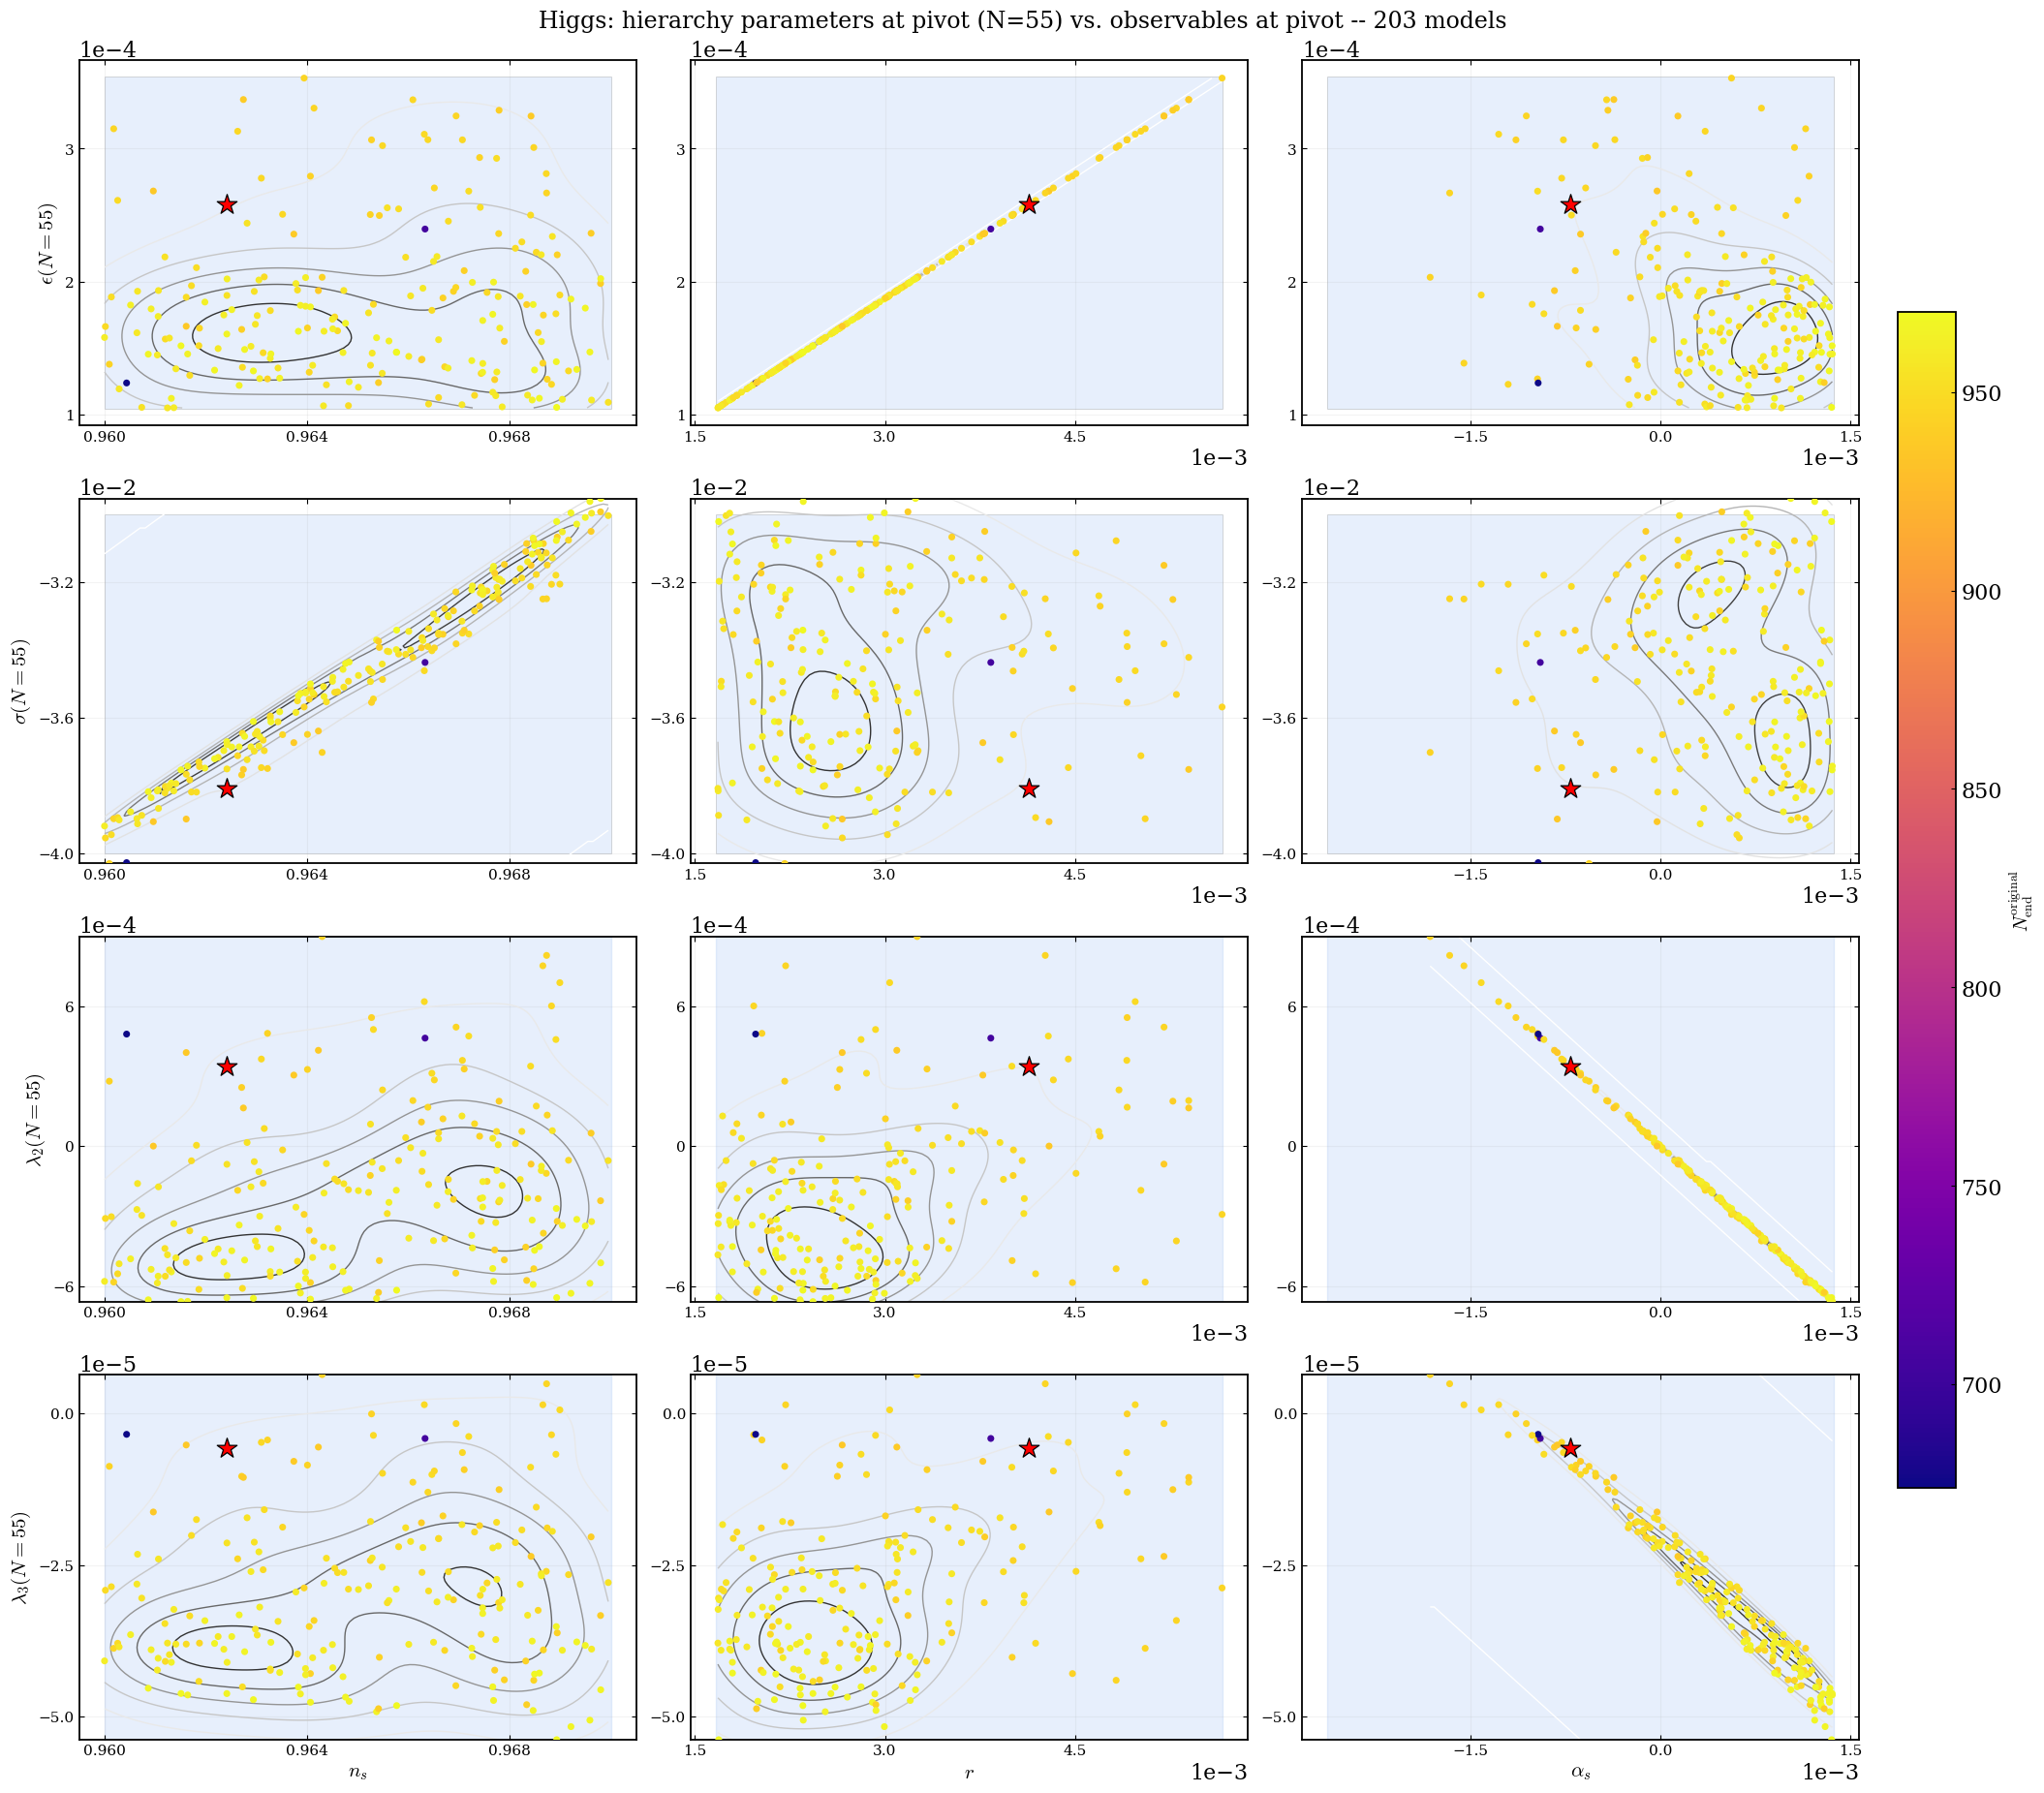

In [24]:
# ============================================================
# CELL 11: Hierarchy parameters AT THE PIVOT (N=55) vs. observables
#          (also at the pivot)
#
# Cell 9 compared pivot observables (n_s, r, alpha_s) against the
# N=60 SEED values of eps/sig/lam2-5. This cell instead interpolates
# each hierarchy parameter's actual trajectory to N=55, using the
# same state-vector layout as Cell 6's process_trajectory:
#   col 0 = phi, col 1 = H, col 2 = eps, col 3 = sig,
#   col 4 = lam2, col 5 = lam3, col 6 = lam4, col 7 = lam5,
#   col NEQS = N (for NEQS=8, that's column 8)
#
# NOTE: no y-axis reference box here -- your driver's LAM*_MIN/MAX
# and EPSILON/SIGMA bounds are sampling priors AT N=60, not bounds
# on the evolved N=55 values, so they don't apply to this axis.
# ============================================================

#I wanted to see for all CMB consistent models, what are the parameter values at N=55?
#I have a summary of ns, r, and alphas at Ninit but i wanna see N at 55 too


from pathlib import Path
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from matplotlib.patches import Rectangle

NEQS = 6
model_tag = "higgs"
N_PIVOT = 55.0

#So I can define my parameters that I want, right now i was just looking for srps
STATE_NAMES = ["phi", "H", "eps", "sig", "lam2", "lam3"][:NEQS]

#We can load each trajectory file, so it'll search my batch directory
def load_path_from_outdir(outdir, NEQS=NEQS):
    folder = Path(outdir)
    matches = list(
        folder.glob(f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat")
    )
    if not matches:
        raise FileNotFoundError(f"No path file found in: {outdir}")
    return pd.read_csv(matches[0], sep=r"\s+", header=None).values

#Now I dont explicitly have rthe state at N=55, so i wanna look at that.
def get_pivot_state(outdir, N_pivot=N_PIVOT, NEQS=NEQS):
    """
    Interpolate every hierarchy-flow state variable (phi, H, eps, sig,
    lam2..lam5) to N = N_pivot, from the saved path file in `outdir`.
    """
    data = load_path_from_outdir(outdir, NEQS=NEQS)

    #So find rthe raw N and the states I want
    N_raw = np.asarray(data[:, NEQS], dtype=float) #aka col 6 contains N
    #Generate a dictionary of state cols
    state_cols = {
        name: np.asarray(data[:, k], dtype=float)
        for k, name in enumerate(STATE_NAMES)
    }

    
    #check to make sure path is finite, it should be
    finite = np.isfinite(N_raw)
    for arr in state_cols.values():
        finite &= np.isfinite(arr)

    n_bad = np.count_nonzero(~finite) #we can count invalid rows but there better not be any

    if n_bad > 0: #it'll stop if theres a bad row
        raise ValueError(
            f"Trajectory contains {n_bad} non-finite rows "
            f"out of {len(N_raw)} total rows."
        )

#here we are saving only finite but maybe i should change that
#     N_raw = N_raw[finite]
#     state_cols = {k: v[finite] for k, v in state_cols.items()}
#and i need enough  points there for interpolation
    if len(N_raw) < 2:
        raise ValueError("Not enough finite path points.")
#then i can check for monotinicity, np.diff finds diff bw neighboring values
#dN = -1, -1 if dec, dN=1, 1 if inc or staying const
    dN = np.diff(N_raw)
    if np.all(dN >= 0):
        order = slice(None) #i do nothing if diff between consec pieces is increasing
    elif np.all(dN <= 0):
        order = slice(None, None, -1)#will reverse array if dec, need it for interp
    else:
        raise ValueError("N is non-monotonic; refusing to reorder trajectory.")

    N_use = N_raw[order] #Apply the ordering which is just areversal if needed
    state_use = {k: v[order] for k, v in state_cols.items()} #and apply it to statecol
    #physical pairing is intact

    #We can check to make sure N=55 is in the saved range
    if not (N_use.min() <= N_pivot <= N_use.max()):
        raise ValueError(
            f"N_pivot={N_pivot} outside range [{N_use.min():.4f}, {N_use.max():.4f}]"
        )
#Then we can return the state at N=55
#Very much prelim func, can do better with bspline i think
    return {name: float(np.interp(N_pivot, N_use, arr)) for name, arr in state_use.items()}

#Added a KDE contour, which ius kernal density estimate. shows joint density of two numerical variables
#It uses nested contour lines instead of points
#kde is replacing every model point with a smooth gaussian bump, it add them all together
#to estimate a density field
def add_kde_contour(ax, x, y, levels=5, min_points=10, cmap="Greys"):
    #we check to make sure we have more than 10 models, we betta
    if len(x) < min_points:
        return
    try: #then for each one it'll take given data
        kde = gaussian_kde(np.vstack([x, y]))
        xg = np.linspace(x.min(), x.max(), 100) #make a grid of x points 100 evenly spaced
        yg = np.linspace(y.min(), y.max(), 100) #make grid of y pts 
        XG, YG = np.meshgrid(xg, yg) #makes 100 x 100
        ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape) 
        #will evaluate density at every pt on grid
        ax.contour(XG, YG, ZG, levels=levels, cmap=cmap, linewidths=1.0)
        #then generate contour, itll do five density contour levels
        #they rep model density
    except np.linalg.LinAlgError as e:
        print(f"KDE contour skipped: {e}")
        #if all x and y are identical or duplicates, no contour appears

        #this is gonna draw a shaded rectangle
        #it'll extract x and y bounds
def add_reference_box(ax, x_bounds, y_bounds, color="cornflowerblue", alpha=0.15):
    """One soft shaded rectangle covering both x and y reference ranges."""
    x_lo, x_hi = x_bounds
    y_lo, y_hi = y_bounds
    rect = Rectangle(
        (x_lo, y_lo), x_hi - x_lo, y_hi - y_lo,
        facecolor=color, edgecolor="black", linewidth=0.7,
        alpha=alpha, zorder=0,
    ) #rectangle done
    ax.add_patch(rect)

#reduces number of ticks besdes axis, i have dine numbers
def format_no_offset(ax, max_ticks=3):
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_ticks, prune="both"))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=max_ticks, prune="both"))
    x_fmt = ScalarFormatter(useOffset=False)
    x_fmt.set_powerlimits((-2, 2)) #it'll switch to sci notation outsde of 1e-2 to 1e2
    ax.xaxis.set_major_formatter(x_fmt)
    y_fmt = ScalarFormatter(useOffset=False)
    y_fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(y_fmt)


# --- Observable acceptance window (x-axis shading only) --------------------
NMIN, NMAX = 0.96, 0.97
R_TARGET, R_DELTA = 0.003664125, 0.002
RMIN, RMAX = R_TARGET - R_DELTA, R_TARGET + R_DELTA
# PIVOT_ALPHA_MIN, PIVOT_ALPHA_MAX = -0.000630587, 0.000630587

ALPHA_TARGET = -0.000630587
ALPHA_DELTA = 0.002

PIVOT_ALPHA_MIN = ALPHA_TARGET - ALPHA_DELTA
PIVOT_ALPHA_MAX = ALPHA_TARGET + ALPHA_DELTA

#these are my rows im comparing with each state vec
col_columns = ["n_s", "r", "alpha_s"]
col_labels = {
    "n_s": r"$n_s$",
    "r": r"$r$",
    "alpha_s": r"$\alpha_s$",
}
cut_bounds = {
    "n_s": (NMIN, NMAX),
    "r": (RMIN, RMAX),
    "alpha_s": (PIVOT_ALPHA_MIN, PIVOT_ALPHA_MAX),
}

row_columns = ["eps", "sig", "lam2", "lam3"]
row_labels = {
    "eps": r"$\epsilon(N=55)$",
    "sig": r"$\sigma(N=55)$",
    "lam2": r"$\lambda_2(N=55)$",
    "lam3": r"$\lambda_3(N=55)$"
#     "lam4": r"$\lambda_4(N=55)$",
#     "lam5": r"$\lambda_5(N=55)$",
}

# eps and sig bounds were widened to also cover N=55 (per your driver
# update), so a shaded band on the y-axis is meaningful for these two.
# lam2-5 don't have an equivalent N=55-valid bound, so no band for those.
row_bounds = {
    "eps": (RMIN / 16, RMAX / 16),
    "sig": (NMIN - 1, NMAX - 1),
}

# --- Base model's N=60 seed value (used only to find its row/outdir) ------
param_base_seed = {
    "lam2": 0.000278972,
    "lam3": -4.60971e-6
#     "lam4": 6.87065e-08,
#     "lam5": -8.92461e-9,
}

#find base model with lam2 and lam3
base_mask = (
    np.isclose(
        summary_all["lam2"].to_numpy(dtype=float),
        param_base_seed["lam2"],
        rtol=1e-8,
        atol=max(1e-15, abs(param_base_seed["lam2"]) * 1e-8),
    )
    &
    np.isclose(
        summary_all["lam3"].to_numpy(dtype=float),
        param_base_seed["lam3"],
        rtol=1e-8,
        atol=max(1e-15, abs(param_base_seed["lam3"]) * 1e-8),
    )
)
base_row = summary_all.loc[base_mask].iloc[0]
#then we can find base model value at N=55
base_pivot_state = get_pivot_state(base_row["outdir"], N_pivot=N_PIVOT, NEQS=NEQS)

# --- Build the pivot-evaluated dataset 
#create empty array for this first
pivot_rows = []
#for every model, load and interpolate its path. If missing or invalid it is printed and skips
for _, row in summary_all.iterrows():
    try:
        state = get_pivot_state(row["outdir"], N_pivot=N_PIVOT, NEQS=NEQS)
    except (FileNotFoundError, ValueError) as e:
        print(f"Skipping {row['outdir']}: {e}")
        continue

    #successful modes get appended
    pivot_rows.append({
        **state,
        "n_s": row["n_s"],
        "r": row["r"],
        "alpha_s": row["alpha_s"],
        "original_N_end": row["original_N_end"],
    })

    #this is turned into table
df_pivot = pd.DataFrame(pivot_rows)
n_models = len(df_pivot)
print(f"Pivot-evaluated models: {n_models} / {len(summary_all)}")

#i like plasma
cmap = plt.get_cmap("plasma")
#maps smallest and largest Nend onto colormap range
color_norm = mcolors.Normalize(
    vmin=df_pivot["original_N_end"].min(),
    vmax=df_pivot["original_N_end"].max(),
)
#assigns a color per model
point_colors = cmap(color_norm(df_pivot["original_N_end"]))

# --- Build the grid  rn its a 4x3
n_rows = len(row_columns)
n_cols = len(col_columns)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7.0 * n_cols, 4.6 * n_rows),
    constrained_layout=True,
)

#each panel gets row and col name
for i, row_name in enumerate(row_columns):
    for j, col_name in enumerate(col_columns):
        ax = axes[i, j]

        x = df_pivot[col_name].to_numpy()
        y = df_pivot[row_name].to_numpy()

        x_lo, x_hi = cut_bounds[col_name]
        #it'll draw a box using x and y bounds
        if row_name in row_bounds:
            add_reference_box(ax, cut_bounds[col_name], row_bounds[row_name])
        #for lam3 and lam2 it will shade obs range on x axis
        else:
            ax.axvspan(x_lo, x_hi, color="cornflowerblue", alpha=0.15, zorder=0)

        add_kde_contour(ax, x, y) #this is adding density contours
        #then we can plot every valid model
        ax.scatter(x, y, c=point_colors, s=26, edgecolor="none", alpha=1, zorder=3)
        ax.scatter(
            float(base_row[col_name]), base_pivot_state[row_name],
            marker="*", s=240, color="red",
            edgecolor="black", linewidth=0.9, zorder=10,
        ) #the star is our base model, come from summary table

        if i == n_rows - 1:
            ax.set_xlabel(col_labels[col_name], fontsize=15)
        if j == 0:
            ax.set_ylabel(row_labels[row_name], fontsize=15)

        format_no_offset(ax)
        ax.tick_params(labelsize=11)
        ax.grid(True, alpha=0.15)

sm = cm.ScalarMappable(cmap=cmap, norm=color_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02)
cbar.set_label(r"$N_{\rm end}^{\rm original}$", fontsize=14)
cbar_fmt = ScalarFormatter(useOffset=False)
cbar_fmt.set_scientific(False)
cbar.formatter = cbar_fmt
cbar.update_ticks()

fig.suptitle(
    rf"{MODEL_CONFIG[model_tag]['label']}: hierarchy parameters at pivot "
    rf"(N={N_PIVOT:g}) vs. observables at pivot -- {n_models} models",
    fontsize=17,
)

fig.savefig(
    f"paper_{model_tag}_neqs{NEQS}_pivot_hierarchy_vs_observable_grid.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Gray contours show the kernel-density estimate of the sampled model distribution. It is like shwoing where these models cluster